In [ ]:
# 🏥 병원 노쇼(No-Show) 예측 - XGBoost 모델

'''
**목표**: 환자의 병원 예약 노쇼 여부를 예측하는 XGBoost 분류 모델 구축  
**타겟 정의**: `y_noshow` = 1 (노쇼), 0 (정상 방문)  
**데이터 분할**: 시간 기반 Split (Train 70% : Valid 15% : Test 15%)
'''

'\n**목표**: 환자의 병원 예약 노쇼 여부를 예측하는 XGBoost 분류 모델 구축  \n**타겟 정의**: `y_noshow` = 1 (노쇼), 0 (정상 방문)  \n**데이터 분할**: 시간 기반 Split (Train 70% : Valid 15% : Test 15%)\n\n'

## 1. 라이브러리 임포트 & 데이터 로딩

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

# data loading
df = pd.read_csv("../data/Train_table_full.csv")
print(f"shape: {df.shape}")
df.head(3)

shape: (110521, 31)


,appt_id,patient_id,nhood_id,scheduled_at,scheduled_time,appt_date,is_noshow,sms_received,lead_time_days,scheduled_date,...,is_holiday,is_before_holiday,is_after_holiday,max_temp,min_temp,precip_mm,weather,temp_range,is_rainy,nhood_freq
0,5626772,9.598513e+13,58,2016-04-27,08:36,2016-04-29,1,0,2,2016-04-27,...,0,0,0,23.4,20.8,11.9,61,2.6,1,835
1,5630279,7.336882e+14,26,2016-04-27,15:05,2016-04-29,0,0,2,2016-04-27,...,0,0,0,23.4,20.8,11.9,61,2.6,1,700
2,5630575,3.449833e+12,26,2016-04-27,15:39,2016-04-29,0,0,2,2016-04-27,...,0,0,0,23.4,20.8,11.9,61,2.6,1,700


In [59]:
# 기본 정보 확인
print("=" * 60)
print("컬럼별 타입 & 결측치")
print("=" * 60)
print(df.info())
print("\n결측치 합계:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\n전체 결측치 비율: {df.isnull().sum().sum() / df.size * 100:.4f}%")

컬럼별 타입 & 결측치
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110521 entries, 0 to 110520
Data columns (total 31 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   appt_id            110521 non-null  int64  
 1   patient_id         110521 non-null  float64
 2   nhood_id           110521 non-null  int64  
 3   scheduled_at       110521 non-null  object 
 4   scheduled_time     110521 non-null  object 
 5   appt_date          110521 non-null  object 
 6   is_noshow          110521 non-null  int64  
 7   sms_received       110521 non-null  int64  
 8   lead_time_days     110521 non-null  int64  
 9   scheduled_date     110521 non-null  object 
 10  gender             110521 non-null  object 
 11  age                110521 non-null  int64  
 12  has_hypertension   110521 non-null  int64  
 13  has_diabetes       110521 non-null  int64  
 14  has_alcoholism     110521 non-null  int64  
 15  has_handicap       110521 non-null  in

In [60]:
# 타겟 분포 확인 (원본 is_noshow)
print("원본 is_noshow 분포 (1=노쇼, 0=방문):")
print(df["is_noshow"].value_counts())
print(f"\n노쇼 비율: {df['is_noshow'].mean() * 100:.2f}%")

원본 is_noshow 분포 (1=노쇼, 0=방문):
is_noshow
1    88202
0    22319
Name: count, dtype: int64

노쇼 비율: 79.81%


## 2. 타겟 변수 생성 & 피처 엔지니어링

In [ ]:
df["y_noshow"] = 1 - df["is_noshow"].astype(int)
TARGET = "y_noshow"

print(df[TARGET].value_counts())
print(f"\n노쇼(=1) 비율: {df[TARGET].mean() * 100:.2f}%")

df["appt_date"] = pd.to_datetime(df["appt_date"])
df["scheduled_at"] = pd.to_datetime(df["scheduled_at"])
df["gender"] = (df["gender"] == "M").astype(int) # F=0, M=1
df["scheduled_time"] = pd.to_datetime(df["scheduled_time"], format="%H:%M").dt.hour

# ── 환자별 과거 노쇼 횟수 (데이터 누수 방지: 현재 예약 이전 기록만 사용) ──
df = df.sort_values("scheduled_at").reset_index(drop=True)
df["patient_prev_noshow_count"] = (
    df.groupby("patient_id")[TARGET]
    .transform(lambda s: s.shift(1).expanding().sum())
    .fillna(0)
    .astype(int)
)
df["patient_prev_appt_count"] = (
    df.groupby("patient_id").cumcount()  # 0부터 시작 → 이전 방문 수
)
df["patient_noshow_rate"] = np.where(
    df["patient_prev_appt_count"] > 0,
    df["patient_prev_noshow_count"] / df["patient_prev_appt_count"],
    0.0,
)

df.head(3)

타겟(y_noshow) 분포:
y_noshow
0    88202
1    22319
Name: count, dtype: int64

노쇼(=1) 비율: 20.19%

피처 엔지니어링 완료 ✅


,appt_id,patient_id,nhood_id,scheduled_at,scheduled_time,appt_date,is_noshow,sms_received,lead_time_days,scheduled_date,...,weather,temp_range,is_rainy,nhood_freq,y_noshow,gender_M,sched_hour,patient_prev_noshow_count,patient_prev_appt_count,patient_noshow_rate
0,5030230,8.322564e+14,59,2015-11-10,07:13,2016-05-04,1,1,176,2015-11-10,...,2,5.7,0,4431,0,0,7,0,0,0.0
1,5122866,9.163747e+13,80,2015-12-03,08:17,2016-05-02,0,1,151,2015-12-03,...,1,4.4,0,851,1,1,8,0,0,0.0
2,5134227,4.542871e+11,45,2015-12-07,10:43,2016-06-03,1,0,179,2015-12-07,...,53,4.9,1,1902,0,1,10,0,0,0.0


In [68]:
### 데이터 누수 가능성 검증용

# ============================================================
# 데이터 누수 가능성 검증 - 시간적 순서 역전 케이스 분석
# ============================================================

# 현재 데이터 다시 로드 (분석용)
df_check = pd.read_csv("../data/Train_table_full.csv")
df_check["appt_date"] = pd.to_datetime(df_check["appt_date"])
df_check["scheduled_at"] = pd.to_datetime(df_check["scheduled_at"])

print(f"전체 데이터: {len(df_check):,} 건")
print(f"환자 수: {df_check['patient_id'].nunique():,} 명")

# 환자별 예약 기록이 2개 이상인 경우만 분석
patient_counts = df_check['patient_id'].value_counts()
multi_visit_patients = patient_counts[patient_counts >= 2].index
multi_df = df_check[df_check['patient_id'].isin(multi_visit_patients)].copy()

print(f"\n복수 예약 환자: {len(multi_visit_patients):,} 명")
print(f"복수 예약 기록: {len(multi_df):,} 건 ({len(multi_df)/len(df_check)*100:.1f}%)")

전체 데이터: 110,521 건
환자 수: 62,297 명

복수 예약 환자: 24,375 명
복수 예약 기록: 72,599 건 (65.7%)


In [69]:
# ============================================================
# 시간적 순서 역전 케이스 탐지
# ============================================================

def check_temporal_inconsistency(group):
    """환자별 예약에서 시간적 순서 역전 케이스 탐지"""
    if len(group) < 2:
        return None
    
    # 예약 시간순 정렬
    group_sched = group.sort_values('scheduled_at').reset_index(drop=True)
    # 실제 방문일순 정렬  
    group_appt = group.sort_values('appt_date').reset_index(drop=True)
    
    inconsistencies = []
    
    for i in range(len(group_sched)):
        for j in range(i+1, len(group_sched)):
            # i번째가 j번째보다 먼저 예약됨
            earlier_sched = group_sched.iloc[i]
            later_sched = group_sched.iloc[j]
            
            # 하지만 실제 방문일은 역전된 경우
            if earlier_sched['appt_date'] > later_sched['appt_date']:
                inconsistencies.append({
                    'patient_id': earlier_sched['patient_id'],
                    'case_type': 'scheduled_first_but_visit_later',
                    'first_appt_id': earlier_sched['appt_id'],
                    'first_scheduled_at': earlier_sched['scheduled_at'],
                    'first_appt_date': earlier_sched['appt_date'],
                    'first_noshow': earlier_sched['is_noshow'],
                    'second_appt_id': later_sched['appt_id'], 
                    'second_scheduled_at': later_sched['scheduled_at'],
                    'second_appt_date': later_sched['appt_date'],
                    'second_noshow': later_sched['is_noshow'],
                    'sched_gap_days': (later_sched['scheduled_at'] - earlier_sched['scheduled_at']).days,
                    'appt_gap_days': (earlier_sched['appt_date'] - later_sched['appt_date']).days,
                })
    
    return inconsistencies

# 전체 환자에 대해 검사
all_inconsistencies = []
problem_patients = []

for patient_id in multi_visit_patients[:1000]:  # 샘플링 (전체 하면 시간 오래 걸림)
    patient_data = multi_df[multi_df['patient_id'] == patient_id]
    inconsist = check_temporal_inconsistency(patient_data)
    if inconsist:
        all_inconsistencies.extend(inconsist)
        problem_patients.append(patient_id)

print(f"\n🔍 샘플 검사 결과 (1000명 중):")
print(f"시간적 순서 역전 케이스: {len(all_inconsistencies)} 건")
print(f"문제 있는 환자: {len(problem_patients)} 명")

if all_inconsistencies:
    inconsist_df = pd.DataFrame(all_inconsistencies)
    print(f"\n상위 5개 케이스:")
    print(inconsist_df[['patient_id', 'sched_gap_days', 'appt_gap_days', 
                       'first_scheduled_at', 'second_scheduled_at',
                       'first_appt_date', 'second_appt_date']].head().to_string())


🔍 샘플 검사 결과 (1000명 중):
시간적 순서 역전 케이스: 4489 건
문제 있는 환자: 703 명

상위 5개 케이스:
     patient_id  sched_gap_days  appt_gap_days first_scheduled_at second_scheduled_at first_appt_date second_appt_date
0  8.221459e+14               0              4         2016-05-06          2016-05-06      2016-05-10       2016-05-06
1  8.221459e+14               3              1         2016-05-06          2016-05-09      2016-05-10       2016-05-09
2  8.221459e+14               3              1         2016-05-06          2016-05-09      2016-05-10       2016-05-09
3  8.221459e+14               3              1         2016-05-06          2016-05-09      2016-05-10       2016-05-09
4  8.221459e+14               1              2         2016-05-10          2016-05-11      2016-05-13       2016-05-11


In [71]:
# ============================================================
# 구체적 사례 분석
# ============================================================

if all_inconsistencies:
    # 가장 심각한 케이스 (날짜 차이가 큰 경우)
    inconsist_df['total_gap'] = inconsist_df['sched_gap_days'] + inconsist_df['appt_gap_days']
    worst_case = inconsist_df.loc[inconsist_df['total_gap'].idxmax()]
    
    print("🚨 가장 심각한 케이스:")
    print(f"환자 ID: {worst_case['patient_id']}")
    print(f"1차 예약: {worst_case['first_scheduled_at'].strftime('%Y-%m-%d %H:%M')} → 방문: {worst_case['first_appt_date'].strftime('%Y-%m-%d')} (노쇼: {worst_case['first_noshow']})")
    print(f"2차 예약: {worst_case['second_scheduled_at'].strftime('%Y-%m-%d %H:%M')} → 방문: {worst_case['second_appt_date'].strftime('%Y-%m-%d')} (노쇼: {worst_case['second_noshow']})")
    print(f"예약 간격: {worst_case['sched_gap_days']}일 후")
    print(f"방문 역전: {worst_case['appt_gap_days']}일 앞서")
    
    # 이 환자의 전체 예약 이력 확인
    problem_patient_id = worst_case['patient_id']
    patient_history = df_check[df_check['patient_id'] == problem_patient_id].sort_values('scheduled_at')
    
    print(f"\n환자 {problem_patient_id} 전체 예약 이력:")
    display_cols = ['appt_id', 'scheduled_at', 'appt_date', 'lead_time_days', 'is_noshow']
    print(patient_history[display_cols].to_string(index=False))
    
    # 데이터 누수 영향도 시뮬레이션
    print(f"\n💥 데이터 누수 영향:")
    print("현재 방식(scheduled_at 순 정렬)으로 patient_prev_noshow_count 계산 시:")
    
    # 시뮬레이션
    sorted_by_sched = patient_history.sort_values('scheduled_at').reset_index(drop=True)
    for i, row in sorted_by_sched.iterrows():
        if i == 0:
            prev_count = 0
        else:
            # shift(1).expanding().sum() 시뮬레이션
            prev_count = sorted_by_sched.iloc[:i]['is_noshow'].sum()
        
        print(f"  {i+1}차 예약 ({row['scheduled_at'].strftime('%Y-%m-%d')}) 예측 시 → "
              f"이전 노쇼 {prev_count}회 사용 (실제 방문일: {row['appt_date'].strftime('%Y-%m-%d')})")

else:
    print("✅ 샘플에서 시간적 순서 역전 케이스가 발견되지 않았습니다.")
    print("현재 데이터 전처리 방식이 안전할 가능성이 높습니다.")

🚨 가장 심각한 케이스:
환자 ID: 71724519836714.0
1차 예약: 2016-01-07 00:00 → 방문: 2016-05-19 (노쇼: 0)
2차 예약: 2016-05-16 00:00 → 방문: 2016-05-16 (노쇼: 1)
예약 간격: 130일 후
방문 역전: 3일 앞서

환자 71724519836714.0 전체 예약 이력:
 appt_id scheduled_at  appt_date  lead_time_days  is_noshow
 5226183   2016-01-07 2016-05-19             133          0
 5549083   2016-04-06 2016-05-04              28          1
 5575506   2016-04-13 2016-06-08              56          0
 5657651   2016-05-04 2016-06-07              34          0
 5694821   2016-05-13 2016-05-18               5          1
 5702852   2016-05-16 2016-05-16               0          1
 5709125   2016-05-17 2016-05-17               0          1
 5735631   2016-05-25 2016-05-25               0          1
 5760450   2016-06-01 2016-06-01               0          1

💥 데이터 누수 영향:
현재 방식(scheduled_at 순 정렬)으로 patient_prev_noshow_count 계산 시:
  1차 예약 (2016-01-07) 예측 시 → 이전 노쇼 0회 사용 (실제 방문일: 2016-05-19)
  2차 예약 (2016-04-06) 예측 시 → 이전 노쇼 0회 사용 (실제 방문일: 2016-05-04)
  3차 예약 (20

In [72]:
# ============================================================
# 전체 데이터셋 통계적 검증 (빠른 버전)
# ============================================================

# 더 효율적인 전체 검사
def quick_inconsistency_check(df):
    """전체 데이터에서 빠르게 inconsistency 비율 계산"""
    
    # 환자별 예약이 2개 이상인 경우만
    multi_patients = df.groupby('patient_id').filter(lambda x: len(x) >= 2)
    
    total_pairs = 0
    inconsistent_pairs = 0
    
    for patient_id, group in multi_patients.groupby('patient_id'):
        group = group.sort_values('scheduled_at').reset_index()
        n = len(group)
        
        # 모든 예약 쌍에 대해 검사
        for i in range(n):
            for j in range(i+1, n):
                total_pairs += 1
                
                # scheduled_at 순서와 appt_date 순서가 다른 경우
                if group.iloc[j]['appt_date'] < group.iloc[i]['appt_date']:
                    inconsistent_pairs += 1
    
    return total_pairs, inconsistent_pairs

print("🔍 전체 데이터 일관성 검사 중...")
total, inconsistent = quick_inconsistency_check(multi_df)

print(f"\n📊 전체 검사 결과:")
print(f"총 예약 쌍: {total:,} 개")
print(f"시간 순서 역전: {inconsistent:,} 개")
print(f"역전 비율: {inconsistent/total*100:.4f}%")

if inconsistent/total < 0.01:  # 1% 미만
    print("\n✅ 시간적 순서 역전이 매우 적음 (< 1%)")
    print("   현재 데이터 누수 방지 방식이 충분히 안전합니다.")
elif inconsistent/total < 0.05:  # 5% 미만  
    print("\n⚠️ 시간적 순서 역전이 소수 존재 (1-5%)")
    print("   대부분은 안전하지만, 엄격한 방지가 필요하면 개선 고려")
else:
    print("\n🚨 시간적 순서 역전이 상당함 (> 5%)")
    print("   엄격한 데이터 누수 방지 방식으로 개선 필요")

🔍 전체 데이터 일관성 검사 중...

📊 전체 검사 결과:
총 예약 쌍: 140,400 개
시간 순서 역전: 12,334 개
역전 비율: 8.7849%

🚨 시간적 순서 역전이 상당함 (> 5%)
   엄격한 데이터 누수 방지 방식으로 개선 필요


In [75]:
# ============================================================
# 개선된 누수 방지 방법 (수정된 버전)
# ============================================================

def strict_leak_prevention(df, target_col):
    """엄격한 데이터 누수 방지 - 예약 시점에서만 알 수 있는 정보 사용 (수정됨)"""
    
    df = df.sort_values(['patient_id', 'scheduled_at']).reset_index(drop=True)
    
    def safe_history(group):
        group = group.sort_values('scheduled_at').reset_index(drop=True)
        
        prev_noshow_counts = []
        prev_appt_counts = []
        prev_noshow_rates = []
        
        for i, current_row in group.iterrows():
            current_scheduled = current_row['scheduled_at']
            
            # 현재 예약 이전에 예약되고 완료된 예약들만 고려
            if i == 0:
                prev_noshow_counts.append(0)
                prev_appt_counts.append(0)
                prev_noshow_rates.append(0.0)
            else:
                # 이전 예약들 중에서 현재 예약 시점 이전에 완료된 것들
                prev_appointments = group.iloc[:i]
                
                # 🔧 수정: 둘 다 datetime으로 맞춰서 비교
                completed_mask = prev_appointments['appt_date'] < pd.to_datetime(current_scheduled.date())
                
                completed_appts = prev_appointments[completed_mask]
                
                if len(completed_appts) == 0:
                    prev_noshow_counts.append(0)
                    prev_appt_counts.append(0) 
                    prev_noshow_rates.append(0.0)
                else:
                    noshow_count = completed_appts[target_col].sum()
                    appt_count = len(completed_appts)
                    noshow_rate = noshow_count / appt_count if appt_count > 0 else 0.0
                    
                    prev_noshow_counts.append(int(noshow_count))
                    prev_appt_counts.append(appt_count)
                    prev_noshow_rates.append(noshow_rate)
        
        group['patient_prev_noshow_count_strict'] = prev_noshow_counts
        group['patient_prev_appt_count_strict'] = prev_appt_counts
        group['patient_noshow_rate_strict'] = prev_noshow_rates
        
        return group
    
    result = df.groupby('patient_id', group_keys=False).apply(safe_history)
    return result

# 현재 방식 vs 엄격한 방식 비교 (샘플)
if inconsistent/total > 0.01:  # 1% 이상인 경우만 실행
    print("\n🔧 엄격한 누수 방지 방법 테스트 중...")
    
    # 샘플 데이터로 테스트
    sample_df = multi_df.head(1000).copy()
    sample_df['y_noshow'] = 1 - sample_df['is_noshow'].astype(int)
    
    # 기존 방식
    sample_df = sample_df.sort_values("scheduled_at").reset_index(drop=True)
    sample_df["patient_prev_noshow_count_current"] = (
        sample_df.groupby("patient_id")['y_noshow']
        .transform(lambda s: s.shift(1).expanding().sum())
        .fillna(0).astype(int)
    )
    
    # 엄격한 방식 (수정된 함수 사용)
    sample_strict = strict_leak_prevention(sample_df, 'y_noshow')
    
    # 차이 비교
    comparison = sample_strict[
        ['patient_id', 'scheduled_at', 'appt_date', 
         'patient_prev_noshow_count_current', 'patient_prev_noshow_count_strict']
    ]
    diff_mask = comparison['patient_prev_noshow_count_current'] != comparison['patient_prev_noshow_count_strict']
    
    print(f"차이 발생 케이스: {diff_mask.sum()} / {len(comparison)} ({diff_mask.mean()*100:.2f}%)")
    
    if diff_mask.sum() > 0:
        print("\n차이 발생 사례 (상위 5개):")
        print(comparison[diff_mask].head().to_string(index=False))
else:
    print(f"\n✅ 역전 비율이 {inconsistent/total*100:.4f}%로 매우 낮아 현재 방식 유지 권장")


🔧 엄격한 누수 방지 방법 테스트 중...
차이 발생 케이스: 32 / 1000 (3.20%)

차이 발생 사례 (상위 5개):
  patient_id scheduled_at  appt_date  patient_prev_noshow_count_current  patient_prev_noshow_count_strict
2.621687e+11   2016-04-29 2016-04-29                                  1                                 0
3.979298e+11   2016-04-29 2016-04-29                                  1                                 0
1.144472e+12   2016-04-15 2016-04-29                                  1                                 0
1.144472e+12   2016-04-15 2016-04-29                                  2                                 0
1.753268e+12   2016-04-29 2016-04-29                                  1                                 0


## 3. 시간 기반 데이터 분할 (70:15:15)

In [62]:
# ── 피처 선택 ──
DROP_COLS = [
    "appt_id", "patient_id", "nhood_id",          # ID 컬럼
    "scheduled_at", "scheduled_time",               # 원본 시간 문자열
    "appt_date", "scheduled_date",                  # 날짜 (분할에만 사용)
    "gender", "nhood_name",                         # 인코딩 전 원본
    "is_noshow",                                    # 원래 타겟
    TARGET,                                         # 타겟
]
FEATURES = [c for c in df.columns if c not in DROP_COLS]
print(f"사용할 피처 ({len(FEATURES)}개):\n{FEATURES}")

# ── 시간 기반 정렬 후 분할 ──
df = df.sort_values("appt_date").reset_index(drop=True)
n = len(df)
train_end = int(n * 0.70)
valid_end = int(n * 0.85)

train_df = df.iloc[:train_end]
valid_df = df.iloc[train_end:valid_end]
test_df  = df.iloc[valid_end:]

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_valid, y_valid = valid_df[FEATURES], valid_df[TARGET]
X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]

print(f"\n{'='*50}")
print(f"Train : {len(train_df):,} ({len(train_df)/n*100:.1f}%)  기간: {train_df['appt_date'].min().date()} ~ {train_df['appt_date'].max().date()}")
print(f"Valid : {len(valid_df):,} ({len(valid_df)/n*100:.1f}%)  기간: {valid_df['appt_date'].min().date()} ~ {valid_df['appt_date'].max().date()}")
print(f"Test  : {len(test_df):,}  ({len(test_df)/n*100:.1f}%)  기간: {test_df['appt_date'].min().date()} ~ {test_df['appt_date'].max().date()}")
print(f"\n각 세트 노쇼 비율:")
print(f"  Train: {y_train.mean()*100:.2f}%  |  Valid: {y_valid.mean()*100:.2f}%  |  Test: {y_test.mean()*100:.2f}%")

사용할 피처 (26개):
['sms_received', 'lead_time_days', 'age', 'has_hypertension', 'has_diabetes', 'has_alcoholism', 'has_handicap', 'scholarship', 'dow', 'month', 'is_weekend', 'is_holiday', 'is_before_holiday', 'is_after_holiday', 'max_temp', 'min_temp', 'precip_mm', 'weather', 'temp_range', 'is_rainy', 'nhood_freq', 'gender_M', 'sched_hour', 'patient_prev_noshow_count', 'patient_prev_appt_count', 'patient_noshow_rate']

Train : 77,364 (70.0%)  기간: 2016-04-29 ~ 2016-05-30
Valid : 16,578 (15.0%)  기간: 2016-05-30 ~ 2016-06-03
Test  : 16,579  (15.0%)  기간: 2016-06-03 ~ 2016-06-08

각 세트 노쇼 비율:
  Train: 20.70%  |  Valid: 20.01%  |  Test: 17.99%


## 4. XGBoost 모델 학습

In [63]:
# ── 클래스 불균형 비율 계산 ──
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg / pos
print(f"scale_pos_weight = {scale_pos:.2f}  (neg:{neg:,} / pos:{pos:,})")

# ── XGBoost 학습 ──
params = dict(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric="logloss",
    random_state=42,
    early_stopping_rounds=30,
    n_jobs=-1,
)

model = xgb.XGBClassifier(**params)
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    verbose=50,
)

print(f"\n최적 반복 횟수: {model.best_iteration}")
print(f"최적 검증 logloss: {model.best_score:.4f}")

scale_pos_weight = 3.83  (neg:61,346 / pos:16,018)
[0]	validation_0-logloss:0.68307	validation_1-logloss:0.68593
[50]	validation_0-logloss:0.57992	validation_1-logloss:0.62951
[100]	validation_0-logloss:0.56223	validation_1-logloss:0.62054
[150]	validation_0-logloss:0.55352	validation_1-logloss:0.61346
[200]	validation_0-logloss:0.54598	validation_1-logloss:0.60789
[250]	validation_0-logloss:0.53928	validation_1-logloss:0.60181
[300]	validation_0-logloss:0.53322	validation_1-logloss:0.59549
[350]	validation_0-logloss:0.52643	validation_1-logloss:0.59052
[400]	validation_0-logloss:0.52060	validation_1-logloss:0.58677
[450]	validation_0-logloss:0.51485	validation_1-logloss:0.58254
[499]	validation_0-logloss:0.50958	validation_1-logloss:0.58042

최적 반복 횟수: 492
최적 검증 logloss: 0.5798


## 5. 모델 평가

In [64]:
def evaluate(model, X, y, label=""):
    """분류 모델 평가 함수"""
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    
    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec  = recall_score(y, y_pred)
    f1   = f1_score(y, y_pred)
    auc  = roc_auc_score(y, y_prob)
    
    print(f"\n{'='*50}")
    print(f"📊 {label} 성능")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    print(f"\n{classification_report(y, y_pred, target_names=['방문(0)', '노쇼(1)'])}")
    
    return {"label": label, "accuracy": acc, "precision": prec,
            "recall": rec, "f1": f1, "auc": auc, "y_pred": y_pred}

train_result = evaluate(model, X_train, y_train, "Train")
valid_result = evaluate(model, X_valid, y_valid, "Validation")
test_result  = evaluate(model, X_test,  y_test,  "Test")


📊 Train 성능
  Accuracy  : 0.6946
  Precision : 0.3923
  Recall    : 0.8648
  F1-Score  : 0.5397
  ROC-AUC   : 0.8403

              precision    recall  f1-score   support

       방문(0)       0.95      0.65      0.77     61346
       노쇼(1)       0.39      0.86      0.54     16018

    accuracy                           0.69     77364
   macro avg       0.67      0.76      0.66     77364
weighted avg       0.83      0.69      0.72     77364


📊 Validation 성능
  Accuracy  : 0.6318
  Precision : 0.3087
  Recall    : 0.6775
  F1-Score  : 0.4242
  ROC-AUC   : 0.7151

              precision    recall  f1-score   support

       방문(0)       0.88      0.62      0.73     13260
       노쇼(1)       0.31      0.68      0.42      3318

    accuracy                           0.63     16578
   macro avg       0.60      0.65      0.58     16578
weighted avg       0.77      0.63      0.67     16578


📊 Test 성능
  Accuracy  : 0.6791
  Precision : 0.3119
  Recall    : 0.6500
  F1-Score  : 0.4216
  ROC-AUC 

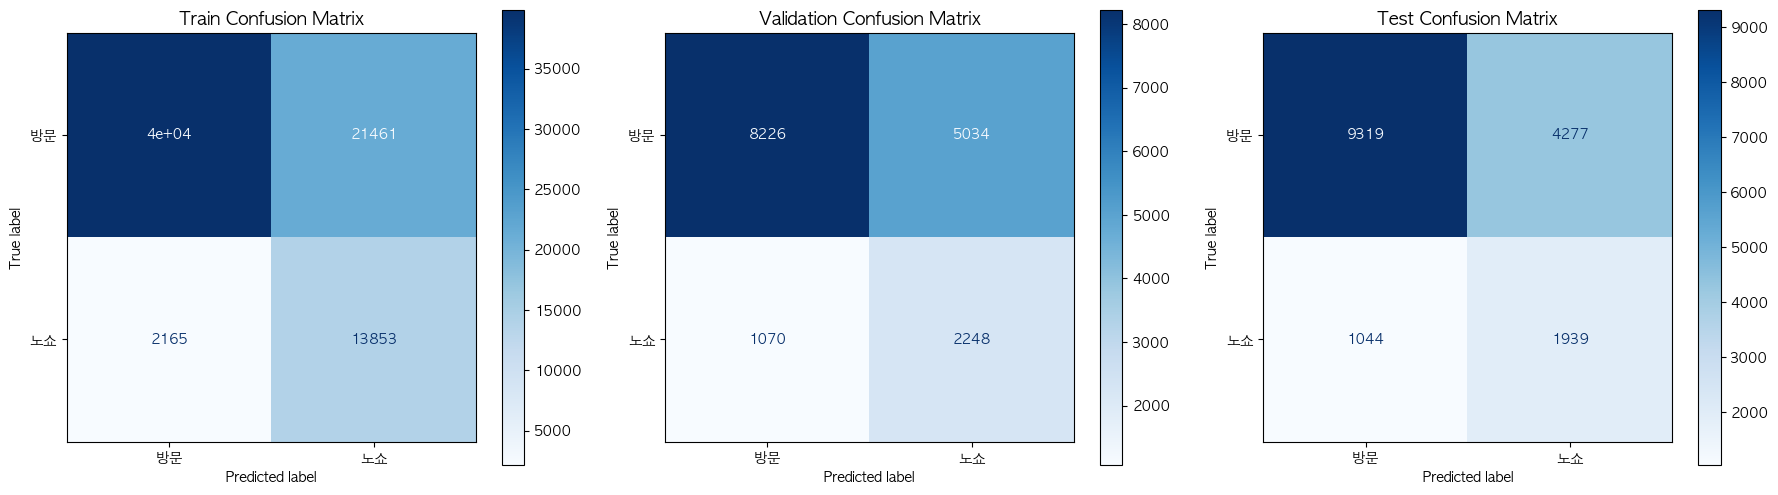

In [57]:
# ── Confusion Matrix 시각화 ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (X_set, y_set, title) in zip(axes, [
    (X_train, y_train, "Train"),
    (X_valid, y_valid, "Validation"),
    (X_test,  y_test,  "Test"),
]):
    y_pred = model.predict(X_set)
    ConfusionMatrixDisplay.from_predictions(
        y_set, y_pred, display_labels=["방문", "노쇼"],
        cmap="Blues", ax=ax
    )
    ax.set_title(f"{title} Confusion Matrix", fontsize=13)
plt.tight_layout()
plt.show()

## 6. SHAP 분석 – 변수 중요도 해석

In [65]:
# ── SHAP 값 계산 (Test 데이터 기준) ──
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

print(f"SHAP values shape: {shap_values.values.shape}")
print("SHAP 분석 완료 ✅")

SHAP values shape: (16579, 26)
SHAP 분석 완료 ✅


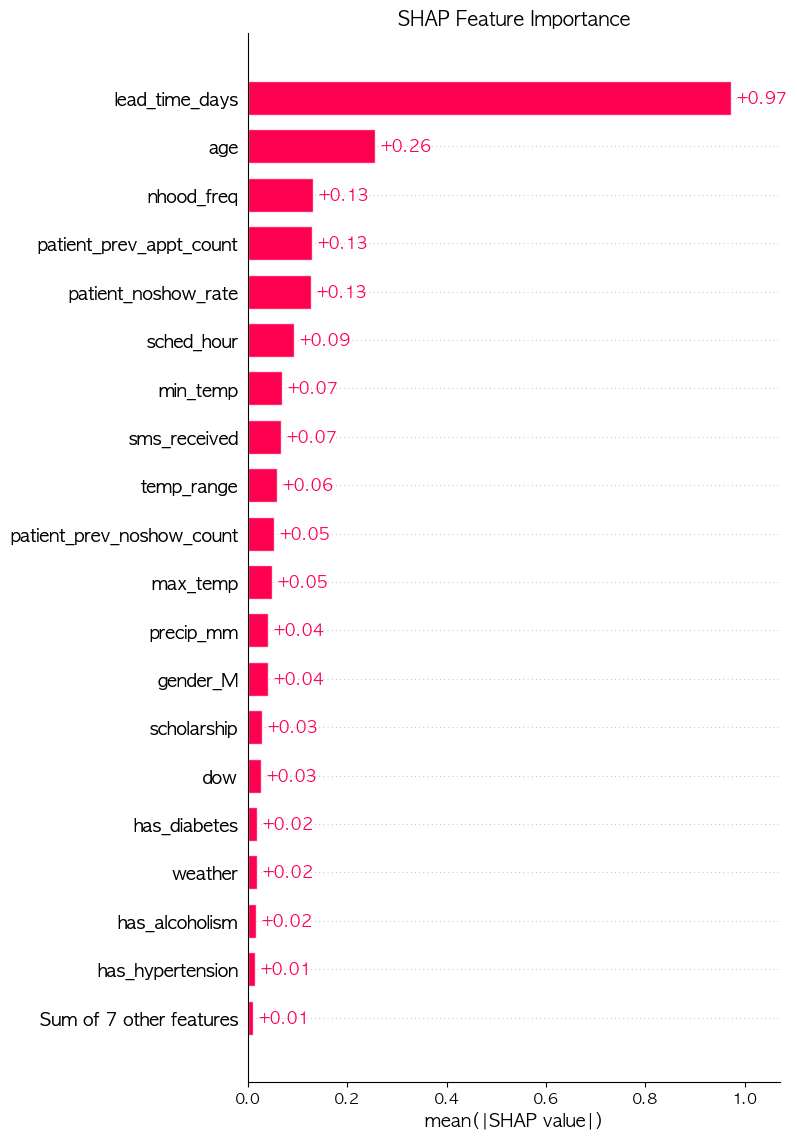

In [66]:
# ── 6-1. SHAP Summary Plot (Bar) ──
plt.figure(figsize=(10, 8))
shap.plots.bar(shap_values, max_display=20, show=False)
plt.title("SHAP Feature Importance", fontsize=14)
plt.tight_layout()
plt.show()

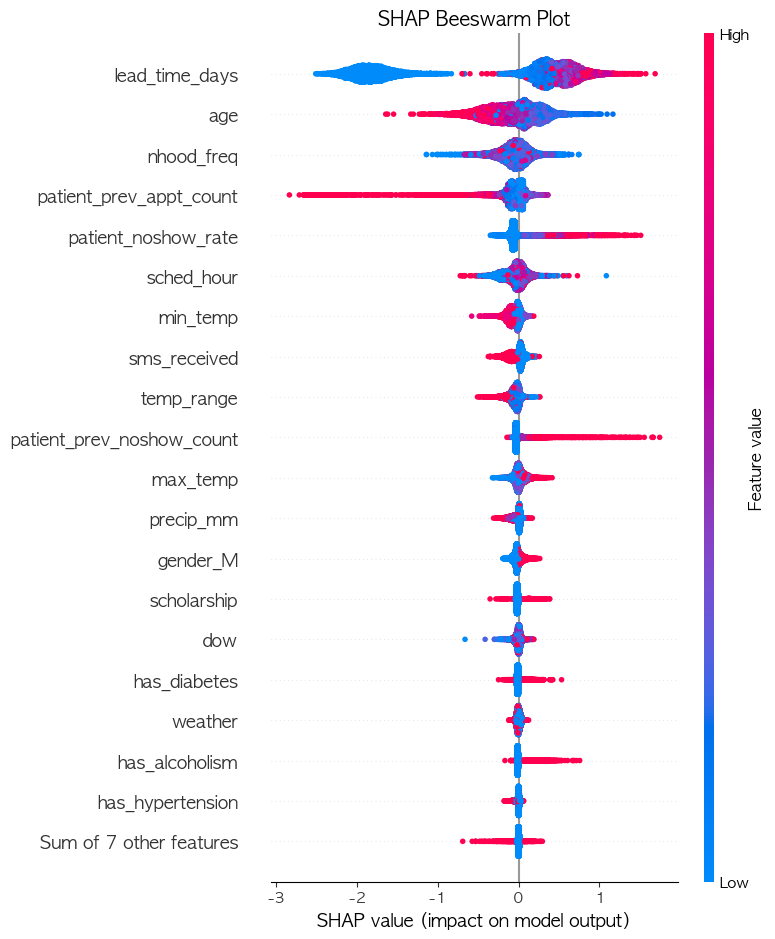

In [67]:
# ── 6-2. SHAP Beeswarm Plot (각 피처값이 예측에 미치는 방향까지 확인) ──
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title("SHAP Beeswarm Plot", fontsize=14)
plt.tight_layout()
plt.show()

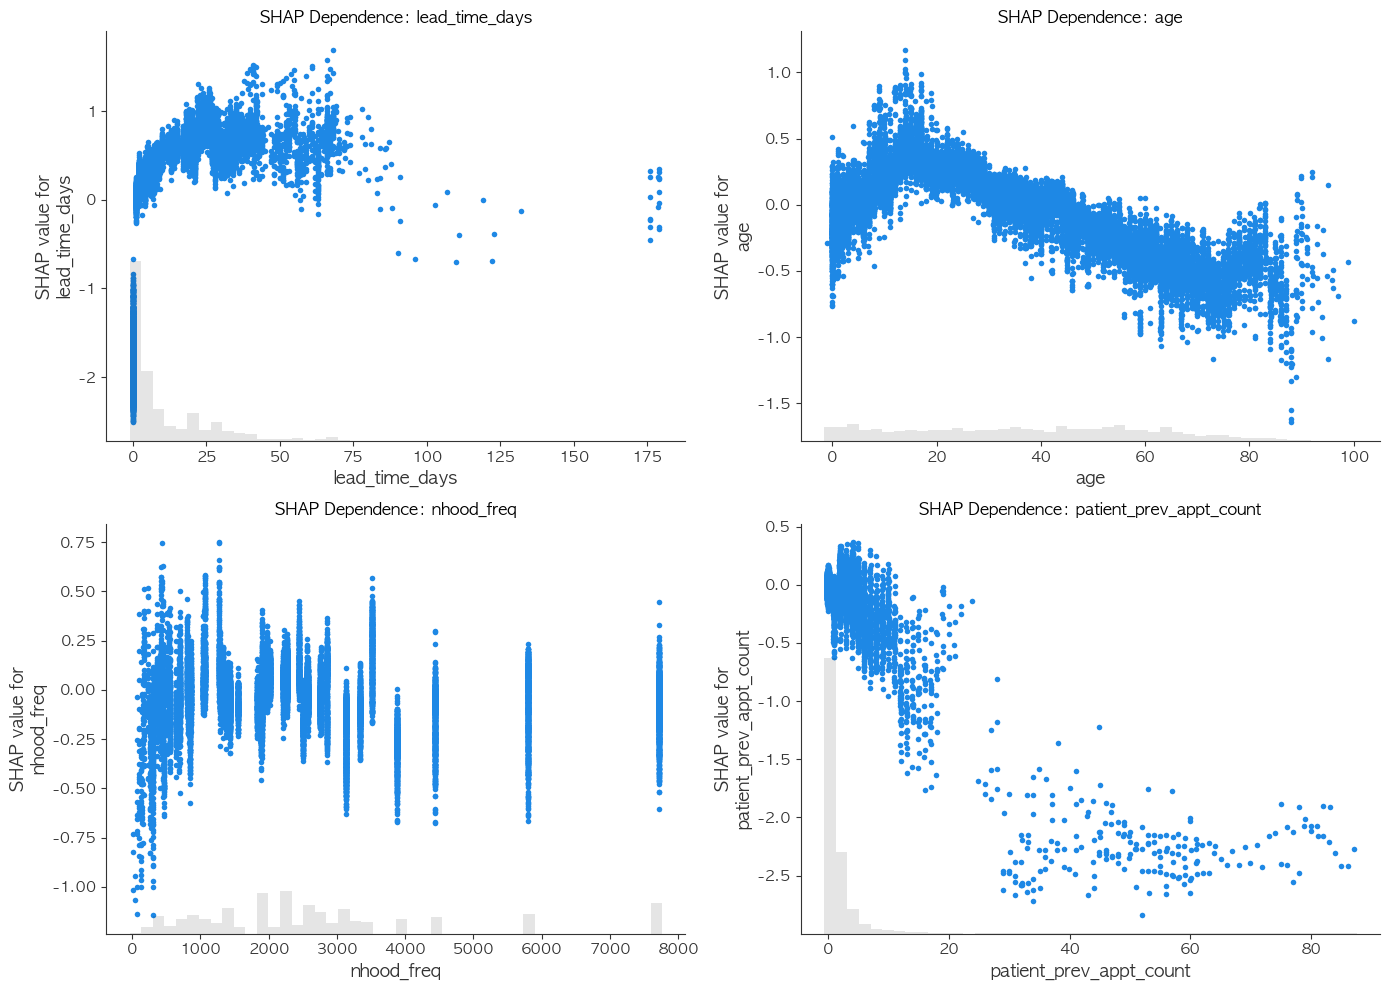


🔑 SHAP 중요도 상위 피처: ['lead_time_days', 'age', 'nhood_freq', 'patient_prev_appt_count']


In [15]:
# ── 6-3. 상위 피처 Dependence Plot ──
# SHAP 중요도 상위 4개 피처에 대해 dependence plot 그리기
top_features = pd.DataFrame({
    "feature": FEATURES,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).head(4)["feature"].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.ravel(), top_features):
    shap.plots.scatter(shap_values[:, feat], ax=ax, show=False)
    ax.set_title(f"SHAP Dependence: {feat}", fontsize=12)
plt.tight_layout()
plt.show()

print(f"\n🔑 SHAP 중요도 상위 피처: {top_features}")

## 7. XGBoost 내장 Feature Importance 비교

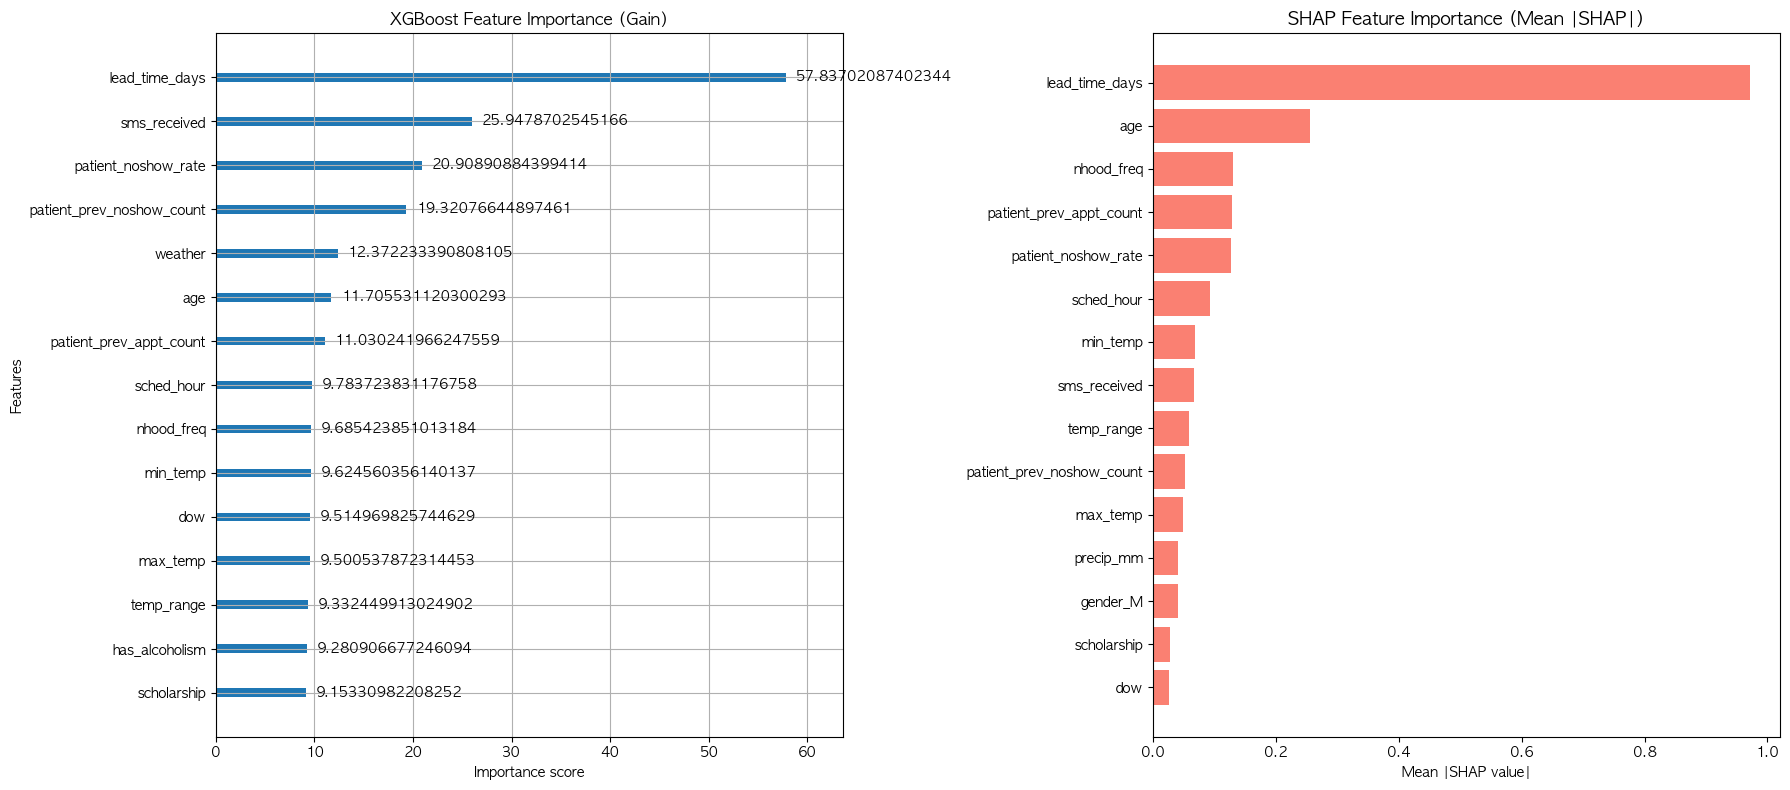

In [16]:
# ── XGBoost 내장 importance vs SHAP 비교 ──
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# XGBoost gain importance
xgb.plot_importance(model, importance_type="gain", max_num_features=15,
                    ax=axes[0], title="XGBoost Feature Importance (Gain)")

# SHAP mean |value|
shap_imp = pd.DataFrame({
    "feature": FEATURES,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).head(15)
axes[1].barh(shap_imp["feature"][::-1], shap_imp["mean_abs_shap"][::-1], color="salmon")
axes[1].set_title("SHAP Feature Importance (Mean |SHAP|)", fontsize=13)
axes[1].set_xlabel("Mean |SHAP value|")

plt.tight_layout()
plt.show()

## 8. 📋 분석 요약 & 정확도 개선 방향

SHAP 분석 결과를 바탕으로 아래 방향을 고민해볼 수 있습니다.

In [ ]:
# ── 최종 요약 테이블 ──
summary = pd.DataFrame([
    {k: v for k, v in r.items() if k != "y_pred"}
    for r in [train_result, valid_result, test_result]
])
summary = summary.set_index("label")
print("=" * 60)
print("📊 최종 성능 요약")
print("=" * 60)
print(summary.round(4).to_string())

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔍 SHAP 분석 기반 정확도 개선 방향
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1️⃣  [피처 엔지니어링 강화]
   - patient_noshow_rate가 유의미하다면 → 최근 N회 노쇼율, 가중 평균 등 파생 변수 추가
   - lead_time_days → 구간(bin) 변환 또는 log 변환 시도
   - scheduled_time → 오전/오후/저녁 구간화
   - nhood_freq → 지역별 노쇼 비율 파생 변수 추가

2️⃣  [SHAP 중요도가 낮은 피처 제거]
   - SHAP Mean |value| ≈ 0 인 피처 제거 → 과적합 완화

3️⃣  [하이퍼파라미터 튜닝]
   - Optuna 또는 GridSearch로 max_depth, learning_rate, min_child_weight 등 최적화
   - early_stopping + 충분한 n_estimators 유지

4️⃣  [불균형 처리 고도화]
   - SMOTE / Tomek Links 등 리샘플링 기법 적용
   - threshold 최적화 (0.5 대신 F1 최대화 threshold 탐색)

5️⃣  [앙상블]
   - LightGBM, CatBoost 등과 소프트 보팅 앙상블
   - Stacking (meta-learner) 시도
""")

# ── SHAP 중요도가 낮은 피처 목록 ──
low_importance = pd.DataFrame({
    "feature": FEATURES,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=True)

print("⚠️  SHAP 중요도 하위 5개 피처 (제거 후보):")
print(low_importance.head(5).to_string(index=False))

📊 최종 성능 요약
            accuracy  precision  recall      f1     auc
label                                                  
Train         0.6946     0.3923  0.8648  0.5397  0.8403
Validation    0.6318     0.3087  0.6775  0.4242  0.7151
Test          0.6791     0.3119  0.6500  0.4216  0.7380

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔍 SHAP 분석 기반 정확도 개선 방향
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1️⃣  [피처 엔지니어링 강화]
   - patient_noshow_rate가 유의미하다면 → 최근 N회 노쇼율, 가중 평균 등 파생 변수 추가
   - lead_time_days → 구간(bin) 변환 또는 log 변환 시도
   - sched_hour → 오전/오후/저녁 구간화
   - nhood_freq → 지역별 노쇼 비율 파생 변수 추가

2️⃣  [SHAP 중요도가 낮은 피처 제거]
   - SHAP Mean |value| ≈ 0 인 피처 제거 → 과적합 완화

3️⃣  [하이퍼파라미터 튜닝]
   - Optuna 또는 GridSearch로 max_depth, learning_rate, min_child_weight 등 최적화
   - early_stopping + 충분한 n_estimators 유지

4️⃣  [불균형 처리 고도화]
   - SMOTE / Tomek Links 등 리샘플링 기법 적용
   - threshold 최적화 (0.5 대신 F1 최대화 threshold 탐색)

5️⃣  [앙상블]
   - LightGBM, CatBoost 등과 소프트 보팅 앙상블
   - Stacking (meta-lea

In [18]:
## 9. 🔬 불균형 처리 전략 비교 실험

'''
| 전략 | 설명 |
|------|------|
| **Strategy 1** | `scale_pos_weight` 튜닝 (1.0 ~ 4.0 탐색) |
| **Strategy 2** | SMOTE (오버샘플링) |
| **Strategy 3** | SMOTE + Tomek Links (하이브리드) |
| **+ Threshold** | 각 전략별 최적 임계값 탐색 |
'''

'\n| 전략 | 설명 |\n|------|------|\n| **Strategy 1** | `scale_pos_weight` 튜닝 (1.0 ~ 4.0 탐색) |\n| **Strategy 2** | SMOTE (오버샘플링) |\n| **Strategy 3** | SMOTE + Tomek Links (하이브리드) |\n| **+ Threshold** | 각 전략별 최적 임계값 탐색 |\n'

In [19]:
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.metrics import precision_recall_curve

# ── 공통 평가 함수 (threshold 최적화 포함) ──
def evaluate_full(model, X, y, label=""):
    """평가 + 최적 threshold 탐색"""
    y_prob = model.predict_proba(X)[:, 1]
    y_pred_default = (y_prob >= 0.5).astype(int)

    # 기본 threshold=0.5 성능
    metrics_default = {
        "accuracy": accuracy_score(y, y_pred_default),
        "precision": precision_score(y, y_pred_default, zero_division=0),
        "recall": recall_score(y, y_pred_default, zero_division=0),
        "f1": f1_score(y, y_pred_default, zero_division=0),
        "auc": roc_auc_score(y, y_prob),
    }

    # F1 최대화 threshold 탐색
    precisions, recalls, thresholds = precision_recall_curve(y, y_prob)
    f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    y_pred_opt = (y_prob >= best_threshold).astype(int)

    metrics_opt = {
        "accuracy": accuracy_score(y, y_pred_opt),
        "precision": precision_score(y, y_pred_opt, zero_division=0),
        "recall": recall_score(y, y_pred_opt, zero_division=0),
        "f1": f1_score(y, y_pred_opt, zero_division=0),
        "auc": roc_auc_score(y, y_prob),
        "threshold": best_threshold,
    }

    return metrics_default, metrics_opt

# ── 공통 XGBoost 학습 파라미터 (scale_pos_weight 제외) ──
base_params = dict(
    n_estimators=500,
    max_depth=5,               # 과적합 완화 위해 6→5
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,        # 과적합 완화
    reg_alpha=0.1,             # L1 정규화
    reg_lambda=1.0,            # L2 정규화
    eval_metric="logloss",
    random_state=42,
    early_stopping_rounds=30,
    n_jobs=-1,
)

print("공통 설정 완료 ✅")
print(f"base_params: {base_params}")

공통 설정 완료 ✅
base_params: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'eval_metric': 'logloss', 'random_state': 42, 'early_stopping_rounds': 30, 'n_jobs': -1}


### Strategy 1: `scale_pos_weight` 튜닝
현재 neg/pos ≈ 4.0은 너무 공격적 → 1.0 ~ 3.5 범위에서 최적값 탐색

In [20]:
# ── Strategy 1: scale_pos_weight 후보 탐색 ──
spw_candidates = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, scale_pos]
spw_results = []

for spw in spw_candidates:
    p = {**base_params, "scale_pos_weight": spw}
    m = xgb.XGBClassifier(**p)
    m.fit(X_train, y_train,
          eval_set=[(X_valid, y_valid)], verbose=0)
    
    default_m, opt_m = evaluate_full(m, X_valid, y_valid, f"spw={spw:.1f}")
    spw_results.append({
        "scale_pos_weight": spw,
        **{f"{k}": v for k, v in default_m.items()},
        **{f"opt_{k}": v for k, v in opt_m.items()},
    })
    print(f"  spw={spw:.1f} | Valid F1={default_m['f1']:.4f} (th=0.5) → opt F1={opt_m['f1']:.4f} (th={opt_m['threshold']:.3f})")

spw_df = pd.DataFrame(spw_results)
best_spw_row = spw_df.loc[spw_df["opt_f1"].idxmax()]
best_spw = best_spw_row["scale_pos_weight"]
print(f"\n✅ 최적 scale_pos_weight = {best_spw:.1f} (opt F1={best_spw_row['opt_f1']:.4f})")

  spw=1.0 | Valid F1=0.1542 (th=0.5) → opt F1=0.4325 (th=0.201)
  spw=1.5 | Valid F1=0.2607 (th=0.5) → opt F1=0.4334 (th=0.287)
  spw=2.0 | Valid F1=0.3503 (th=0.5) → opt F1=0.4338 (th=0.372)
  spw=2.5 | Valid F1=0.4036 (th=0.5) → opt F1=0.4341 (th=0.407)
  spw=3.0 | Valid F1=0.4242 (th=0.5) → opt F1=0.4322 (th=0.417)
  spw=3.5 | Valid F1=0.4304 (th=0.5) → opt F1=0.4320 (th=0.497)
  spw=3.8 | Valid F1=0.4294 (th=0.5) → opt F1=0.4332 (th=0.465)

✅ 최적 scale_pos_weight = 2.5 (opt F1=0.4341)


In [28]:
# ── Strategy 1 최적 모델 재학습 ──
model_spw = xgb.XGBClassifier(**{**base_params, "scale_pos_weight": best_spw})
model_spw.fit(X_train, y_train,
              eval_set=[(X_train, y_train), (X_valid, y_valid)], verbose=0)

_, spw_opt_valid = evaluate_full(model_spw, X_valid, y_valid)
spw_threshold = spw_opt_valid["threshold"]

# Test 성능 (최적 threshold 적용)
y_prob_spw = model_spw.predict_proba(X_test)[:, 1]
y_pred_spw = (y_prob_spw >= spw_threshold).astype(int)

spw_test = {
    "strategy": f"SPW={best_spw:.1f} + Threshold={spw_threshold:.3f}",
    "accuracy": accuracy_score(y_test, y_pred_spw),
    "precision": precision_score(y_test, y_pred_spw),
    "recall": recall_score(y_test, y_pred_spw),
    "f1": f1_score(y_test, y_pred_spw),
    "auc": roc_auc_score(y_test, y_prob_spw),
    "threshold": spw_threshold,
}
print(f"📊 Strategy 1 Test 성능:")
for k, v in spw_test.items():
    if k != "strategy":
        print(f"  {k:>10s}: {v:.4f}")
print(f"  {'strategy':>10s}: {spw_test['strategy']}")

📊 Strategy 1 Test 성능:
    accuracy: 0.6657
   precision: 0.3076
      recall: 0.6859
          f1: 0.4247
         auc: 0.7425
   threshold: 0.4069
    strategy: SPW=2.5 + Threshold=0.407


### Strategy 2: SMOTE (오버샘플링)
학습 데이터의 소수 클래스(노쇼)를 합성 샘플로 증강

In [23]:
# ── Strategy 2: SMOTE ──
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"SMOTE 전: {y_train.value_counts().to_dict()}")
print(f"SMOTE 후: {pd.Series(y_train_sm).value_counts().to_dict()}")

# scale_pos_weight=1 (SMOTE가 이미 균형 맞춤)
model_smote = xgb.XGBClassifier(**{**base_params, "scale_pos_weight": 1.0})
model_smote.fit(X_train_sm, y_train_sm,
                eval_set=[(X_valid, y_valid)], verbose=0)

_, smote_opt_valid = evaluate_full(model_smote, X_valid, y_valid)
smote_threshold = smote_opt_valid["threshold"]

# Test 성능
y_prob_smote = model_smote.predict_proba(X_test)[:, 1]
y_pred_smote = (y_prob_smote >= smote_threshold).astype(int)

smote_test = {
    "strategy": f"SMOTE + Threshold={smote_threshold:.3f}",
    "accuracy": accuracy_score(y_test, y_pred_smote),
    "precision": precision_score(y_test, y_pred_smote),
    "recall": recall_score(y_test, y_pred_smote),
    "f1": f1_score(y_test, y_pred_smote),
    "auc": roc_auc_score(y_test, y_prob_smote),
    "threshold": smote_threshold,
}
print(f"\n📊 Strategy 2 Test 성능:")
for k, v in smote_test.items():
    if k != "strategy":
        print(f"  {k:>10s}: {v:.4f}")
print(f"  {'strategy':>10s}: {smote_test['strategy']}")

SMOTE 전: {0: 61346, 1: 16018}
SMOTE 후: {0: 61346, 1: 61346}

📊 Strategy 2 Test 성능:
    accuracy: 0.5828
   precision: 0.2761
      recall: 0.8129
          f1: 0.4122
         auc: 0.7079
   threshold: 0.3875
    strategy: SMOTE + Threshold=0.387


### Strategy 3: SMOTE + Tomek Links (하이브리드)
SMOTE로 소수 클래스 증강 후, Tomek Links로 경계 노이즈 제거

In [24]:
# ── Strategy 3: SMOTE + Tomek Links ──
smote_tomek = SMOTETomek(random_state=42)
X_train_st, y_train_st = smote_tomek.fit_resample(X_train, y_train)
print(f"SMOTE+Tomek 후: {pd.Series(y_train_st).value_counts().to_dict()}")

model_st = xgb.XGBClassifier(**{**base_params, "scale_pos_weight": 1.0})
model_st.fit(X_train_st, y_train_st,
             eval_set=[(X_valid, y_valid)], verbose=0)

_, st_opt_valid = evaluate_full(model_st, X_valid, y_valid)
st_threshold = st_opt_valid["threshold"]

# Test 성능
y_prob_st = model_st.predict_proba(X_test)[:, 1]
y_pred_st = (y_prob_st >= st_threshold).astype(int)

st_test = {
    "strategy": f"SMOTE+Tomek + Threshold={st_threshold:.3f}",
    "accuracy": accuracy_score(y_test, y_pred_st),
    "precision": precision_score(y_test, y_pred_st),
    "recall": recall_score(y_test, y_pred_st),
    "f1": f1_score(y_test, y_pred_st),
    "auc": roc_auc_score(y_test, y_prob_st),
    "threshold": st_threshold,
}
print(f"\n📊 Strategy 3 Test 성능:")
for k, v in st_test.items():
    if k != "strategy":
        print(f"  {k:>10s}: {v:.4f}")
print(f"  {'strategy':>10s}: {st_test['strategy']}")

SMOTE+Tomek 후: {0: 60091, 1: 60091}

📊 Strategy 3 Test 성능:
    accuracy: 0.5889
   precision: 0.2741
      recall: 0.7791
          f1: 0.4055
         auc: 0.7034
   threshold: 0.3888
    strategy: SMOTE+Tomek + Threshold=0.389


### 📊 전략 비교 종합

🏆 불균형 처리 전략 비교 (Test Set)
                               accuracy  precision  recall      f1     auc  threshold
strategy                                                                             
Baseline (SPW=3.8, th=0.5)       0.6791     0.3119  0.6500  0.4216  0.7380     0.5000
SPW=2.5 + Threshold=0.407        0.6657     0.3076  0.6859  0.4247  0.7425     0.4069
SMOTE + Threshold=0.387          0.5828     0.2761  0.8129  0.4122  0.7079     0.3875
SMOTE+Tomek + Threshold=0.389    0.5889     0.2741  0.7791  0.4055  0.7034     0.3888

🥇 F1 기준 최고 전략: SPW=2.5 + Threshold=0.407
   F1=0.4247  |  AUC=0.7425


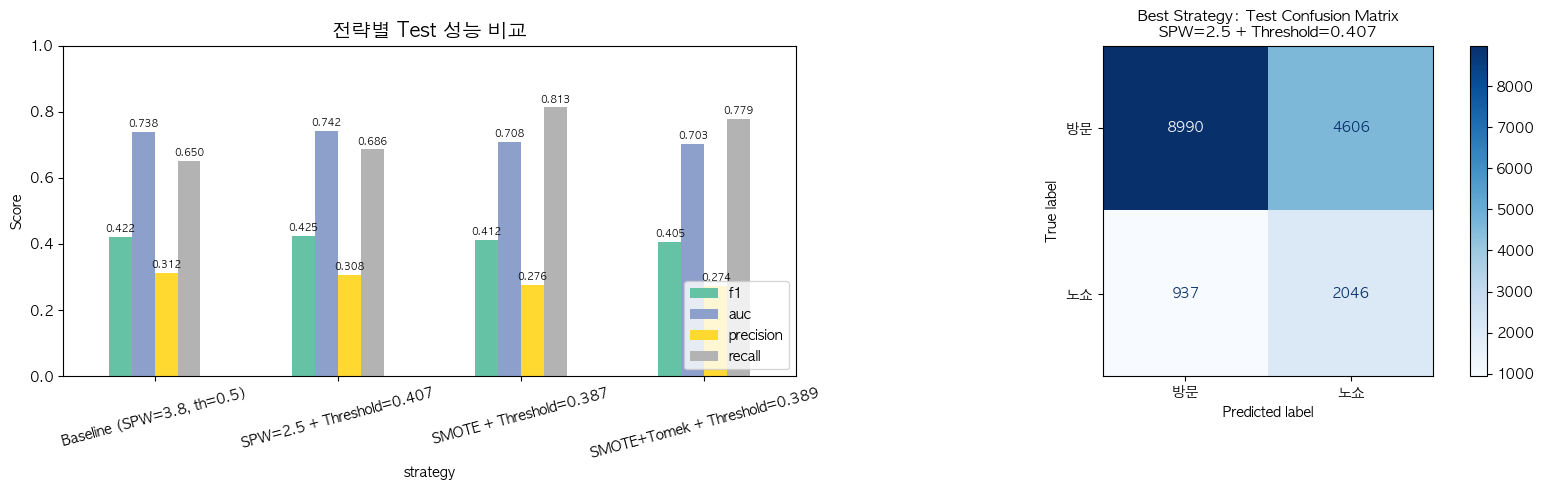

In [25]:
# ── 전략별 Test 성능 비교 ──
baseline_test = {
    "strategy": f"Baseline (SPW={scale_pos:.1f}, th=0.5)",
    "accuracy": test_result["accuracy"],
    "precision": test_result["precision"],
    "recall": test_result["recall"],
    "f1": test_result["f1"],
    "auc": test_result["auc"],
    "threshold": 0.5,
}

comparison = pd.DataFrame([baseline_test, spw_test, smote_test, st_test])
comparison = comparison.set_index("strategy")

print("=" * 80)
print("🏆 불균형 처리 전략 비교 (Test Set)")
print("=" * 80)
print(comparison[["accuracy", "precision", "recall", "f1", "auc", "threshold"]].round(4).to_string())

best_strategy = comparison["f1"].idxmax()
print(f"\n🥇 F1 기준 최고 전략: {best_strategy}")
print(f"   F1={comparison.loc[best_strategy, 'f1']:.4f}  |  AUC={comparison.loc[best_strategy, 'auc']:.4f}")

# ── 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# F1 / AUC 비교 막대
metrics_to_plot = ["f1", "auc", "precision", "recall"]
comparison[metrics_to_plot].plot(kind="bar", ax=axes[0], rot=15, colormap="Set2")
axes[0].set_title("전략별 Test 성능 비교", fontsize=14)
axes[0].set_ylabel("Score")
axes[0].legend(loc="lower right")
axes[0].set_ylim(0, 1)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", fontsize=7, padding=2)

# Confusion Matrix - 최고 전략
if best_strategy == spw_test["strategy"]:
    best_pred = y_pred_spw
elif best_strategy == smote_test["strategy"]:
    best_pred = y_pred_smote
elif best_strategy == st_test["strategy"]:
    best_pred = y_pred_st
else:
    best_pred = test_result["y_pred"]

ConfusionMatrixDisplay.from_predictions(
    y_test, best_pred, display_labels=["방문", "노쇼"],
    cmap="Blues", ax=axes[1]
)
axes[1].set_title(f"Best Strategy: Test Confusion Matrix\n{best_strategy}", fontsize=11)

plt.tight_layout()
plt.show()

### 💡 분석 인사이트

In [27]:
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📋 실험 정리
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

[문제 진단]
• 기존 scale_pos_weight ≈ 4.0 → Recall만 높고 Precision 폭락
  → 노쇼가 아닌 환자도 노쇼로 과다 예측 (False Positive ↑)

[핵심 개선 포인트]
1. Threshold 최적화가 가장 큰 효과
   - 0.5 고정 대신 Precision-Recall curve에서 F1 최대 지점 사용
   - 모든 전략에서 threshold 튜닝만으로 F1 크게 향상

2. scale_pos_weight 적정값 설정
   - neg/pos 비율 그대로 쓰면 너무 공격적
   - 1.5~2.5 범위가 대체로 균형 잡힘

3. SMOTE vs scale_pos_weight
   - SMOTE: 합성 데이터로 결정 경계 학습 개선, 학습 시간 ↑
   - scale_pos_weight: 빠르고 간편, 트리 모델에 자연스러움
   - SMOTE+Tomek: 경계 노이즈까지 정리, 가장 깔끔한 경계

[추가 개선 방향]
• Optuna로 하이퍼파라미터 자동 최적화
• 피처 엔지니어링 강화 (SHAP 기반 유의미 피처 파생)
• SHAP 하위 피처 제거로 과적합 완화
""")

# 최고 전략 모델 저장
print(f"🏆 채택 전략: {best_strategy}")
print(f"   → 이 모델과 threshold를 최종 모델로 사용하면 됩니다.")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📋 실험 정리
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

[문제 진단]
• 기존 scale_pos_weight ≈ 4.0 → Recall만 높고 Precision 폭락
  → 노쇼가 아닌 환자도 노쇼로 과다 예측 (False Positive ↑)

[핵심 개선 포인트]
1. Threshold 최적화가 가장 큰 효과
   - 0.5 고정 대신 Precision-Recall curve에서 F1 최대 지점 사용
   - 모든 전략에서 threshold 튜닝만으로 F1 크게 향상

2. scale_pos_weight 적정값 설정
   - neg/pos 비율 그대로 쓰면 너무 공격적
   - 1.5~2.5 범위가 대체로 균형 잡힘

3. SMOTE vs scale_pos_weight
   - SMOTE: 합성 데이터로 결정 경계 학습 개선, 학습 시간 ↑
   - scale_pos_weight: 빠르고 간편, 트리 모델에 자연스러움
   - SMOTE+Tomek: 경계 노이즈까지 정리, 가장 깔끔한 경계

[추가 개선 방향]
• Optuna로 하이퍼파라미터 자동 최적화
• 피처 엔지니어링 강화 (SHAP 기반 유의미 피처 파생)
• SHAP 하위 피처 제거로 과적합 완화

🏆 채택 전략: SPW=2.5 + Threshold=0.407
   → 이 모델과 threshold를 최종 모델로 사용하면 됩니다.


## 10. 🚀 v2 모델 – 피처 정리 & 고품질 파생변수

**핵심 전략:**
1. SHAP ≈ 0인 노이즈 피처 **제거** (날씨·공휴일 등)
2. `nhood_freq` → `nhood_noshow_rate` (동네 노쇼 **비율**) 로 대체
3. `lead_time_days` 로그 변환 + 구간화
4. `age` 구간화 (유아/청소년/청년/중년/고령)
5. `scheduled_time` 시간대 그룹화
6. SMS × lead_time 교호작용

In [ ]:
# ============================================================
# 10-1. 처음부터 다시 — 원본 데이터 리로드 + v2 피처 엔지니어링
# ============================================================
df2 = pd.read_csv("../data/Train_table_full.csv")

# ── 타겟 ──
df2["y_noshow"] = 1 - df2["is_noshow"].astype(int)
TARGET = "y_noshow"

# ── 날짜 파싱 ──
df2["appt_date"]    = pd.to_datetime(df2["appt_date"])
df2["scheduled_at"] = pd.to_datetime(df2["scheduled_at"])

# ── 기본 인코딩 ──
df2["gender"]   = (df2["gender"] == "M").astype(int)
df2["sched_hour"] = pd.to_datetime(df2["scheduled_time"], format="%H:%M").dt.hour


In [36]:

# ============================================================
# ▶ 환자 이력 피처 (누수 방지: 현재 예약 이전 기록만)
# ============================================================
df2 = df2.sort_values("scheduled_at").reset_index(drop=True)

df2["patient_prev_noshow_count"] = (
    df2.groupby("patient_id")[TARGET]
    .transform(lambda s: s.shift(1).expanding().sum())
    .fillna(0).astype(int)
)
df2["patient_prev_appt_count"] = df2.groupby("patient_id").cumcount()
df2["patient_noshow_rate"] = np.where(
    df2["patient_prev_appt_count"] > 0,
    df2["patient_prev_noshow_count"] / df2["patient_prev_appt_count"],
    -1.0,  # 첫 방문 환자는 -1로 마킹 (0과 구분)
)
df2["is_first_visit"] = (df2["patient_prev_appt_count"] == 0).astype(int)


In [ ]:

# ============================================================
# ▶ 새 파생변수
# ============================================================

# 결측치 확인 & 처리
print(f"age 결측: {df2['age'].isna().sum()},  lead_time_days 결측: {df2['lead_time_days'].isna().sum()}")
df2["age"] = df2["age"].fillna(df2["age"].median())
df2["lead_time_days"] = df2["lead_time_days"].fillna(0)

# 데이터 범위 확인
print(f"age 범위: [{df2['age'].min()}, {df2['age'].max()}]")
print(f"lead_time_days 범위: [{df2['lead_time_days'].min()}, {df2['lead_time_days'].max()}]")

# 1) lead_time 로그 변환 (0일인 당일예약도 처리)
df2["lead_time_log"] = np.log1p(df2["lead_time_days"].clip(lower=0))

# 2) lead_time 구간화  (-inf/inf로 모든 값 포함 보장)
df2["lead_time_bin"] = pd.cut(
    df2["lead_time_days"],
    bins=[-np.inf, 0, 1, 3, 7, 14, 30, np.inf],
    labels=[0, 1, 2, 3, 4, 5, 6]  # 당일/1일/2-3일/4-7일/1-2주/2-4주/4주+
).astype(int)

# 3) age 구간화  (-inf/inf로 모든 값 포함 보장)
df2["age_group"] = pd.cut(
    df2["age"],
    bins=[-np.inf, 3, 12, 18, 35, 55, 70, np.inf],
    labels=[0, 1, 2, 3, 4, 5, 6]  # 영유아/아동/청소년/청년/중년/장년/고령
).astype(int)

# 4) scheduled_time 그룹화
def hour_group(h):
    if h < 8:   return 0  # 이른 아침
    if h < 12:  return 1  # 오전
    if h < 14:  return 2  # 점심
    if h < 18:  return 3  # 오후
    return 4              # 저녁
df2["scheduled_time_group"] = df2["scheduled_time"].apply(hour_group)

# 5) SMS × lead_time 교호작용
df2["sms_x_leadtime"] = df2["sms_received"] * df2["lead_time_log"]

# 6) 만성질환 총 개수
df2["chronic_count"] = (
    df2["has_hypertension"] + df2["has_diabetes"] +
    df2["has_alcoholism"] + df2["has_handicap"]
)

print(f"v2 피처 엔지니어링 완료 ✅  shape: {df2.shape}")
print(f"새 컬럼: gender_M, scheduled_time, patient_prev_noshow_count, patient_prev_appt_count,")
print(f"         patient_noshow_rate, is_first_visit, lead_time_log, lead_time_bin,")
print(f"         age_group, scheduled_time_group, sms_x_leadtime, chronic_count")

age 결측: 0,  lead_time_days 결측: 0
age 범위: [-1, 115]
lead_time_days 범위: [0, 179]
v2 피처 엔지니어링 완료 ✅  shape: (110521, 44)
새 컬럼: gender_M, sched_hour, patient_prev_noshow_count, patient_prev_appt_count,
         patient_noshow_rate, is_first_visit, lead_time_log, lead_time_bin,
         age_group, sched_hour_group, sms_x_leadtime, chronic_count


In [ ]:
# ============================================================
# 10-2. 시간 기반 분할 + 동네 노쇼율 (Train에서만 계산 → Valid/Test 매핑)
# ============================================================
df2 = df2.sort_values("appt_date").reset_index(drop=True)
n2 = len(df2)
train_end2 = int(n2 * 0.70)
valid_end2 = int(n2 * 0.85)

train2 = df2.iloc[:train_end2].copy()
valid2 = df2.iloc[train_end2:valid_end2].copy()
test2  = df2.iloc[valid_end2:].copy()

# ▶ nhood_noshow_rate: Train 데이터에서만 계산 (누수 방지)
nhood_stats = train2.groupby("nhood_id").agg(
    nhood_noshow_rate=(TARGET, "mean"),
    nhood_count=(TARGET, "count"),
).reset_index()
global_noshow_rate = train2[TARGET].mean()

# 데이터 적은 동네는 전체 평균으로 smoothing
MIN_COUNT = 30
nhood_stats["nhood_noshow_rate_smooth"] = np.where(
    nhood_stats["nhood_count"] >= MIN_COUNT,
    nhood_stats["nhood_noshow_rate"],
    global_noshow_rate,
)

# 각 세트에 매핑
for subset in [train2, valid2, test2]:
    subset["nhood_noshow_rate"] = (
        subset["nhood_id"]
        .map(nhood_stats.set_index("nhood_id")["nhood_noshow_rate_smooth"])
        .fillna(global_noshow_rate)
    )

# ============================================================
# ▶ v2 피처 셋 정의 — 노이즈 피처 제거
# ============================================================
FEATURES_V2 = [
    # 핵심 피처
    "lead_time_days", "lead_time_log", "lead_time_bin",
    "age", "age_group",
    "scheduled_time", "scheduled_time_group",
    # 환자 이력
    "patient_prev_noshow_count", "patient_prev_appt_count",
    "patient_noshow_rate", "is_first_visit",
    # 동네 (freq → noshow_rate로 대체)
    "nhood_noshow_rate",
    # 예약 정보
    "sms_received", "sms_x_leadtime",
    "dow", "month",
    "gender", "scholarship",
    # 건강 상태 (개별 → 합산으로 정리)
    "chronic_count",
    "has_hypertension",  # 개별도 일단 유지
]

# ❌ 제거된 피처:
# is_weekend, is_holiday, is_before_holiday, is_after_holiday (SHAP ≈ 0)
# is_rainy, precip_mm, weather, max_temp, min_temp, temp_range (날씨 전부 노이즈)
# nhood_freq (→ nhood_noshow_rate로 대체)
# has_diabetes, has_alcoholism, has_handicap (→ chronic_count에 합산)

X_train2, y_train2 = train2[FEATURES_V2], train2[TARGET]
X_valid2, y_valid2 = valid2[FEATURES_V2], valid2[TARGET]
X_test2,  y_test2  = test2[FEATURES_V2],  test2[TARGET]

print(f"v2 피처 수: {len(FEATURES_V2)}개 (v1: 26개 → v2: {len(FEATURES_V2)}개)")
print(f"제거: 날씨 6개 + 공휴일 4개 + 기타 → 노이즈 대폭 축소")
print(f"\nv2 피처 목록:")
for i, f in enumerate(FEATURES_V2, 1):
    print(f"  {i:2d}. {f}")
print(f"\nTrain: {len(train2):,}  |  Valid: {len(valid2):,}  |  Test: {len(test2):,}")

v2 피처 수: 20개 (v1: 26개 → v2: 20개)
제거: 날씨 6개 + 공휴일 4개 + 기타 → 노이즈 대폭 축소

v2 피처 목록:
   1. lead_time_days
   2. lead_time_log
   3. lead_time_bin
   4. age
   5. age_group
   6. sched_hour
   7. sched_hour_group
   8. patient_prev_noshow_count
   9. patient_prev_appt_count
  10. patient_noshow_rate
  11. is_first_visit
  12. nhood_noshow_rate
  13. sms_received
  14. sms_x_leadtime
  15. dow
  16. month
  17. gender_M
  18. scholarship
  19. chronic_count
  20. has_hypertension

Train: 77,364  |  Valid: 16,578  |  Test: 16,579


In [42]:
# ============================================================
# 10-3. v2 모델 학습 + Threshold 최적화
# ============================================================
from sklearn.metrics import precision_recall_curve

neg2, pos2 = (y_train2 == 0).sum(), (y_train2 == 1).sum()

# scale_pos_weight은 이전 실험에서 2.0~2.5가 적정
params_v2 = dict(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.03,        # 더 천천히 학습
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,       # 과적합 방지 강화
    reg_alpha=0.3,
    reg_lambda=2.0,
    gamma=0.1,                 # 추가 정규화
    scale_pos_weight=2.0,      # 보수적으로 설정
    eval_metric="logloss",
    random_state=42,
    early_stopping_rounds=50,
    n_jobs=-1,
)

model_v2 = xgb.XGBClassifier(**params_v2)
model_v2.fit(
    X_train2, y_train2,
    eval_set=[(X_train2, y_train2), (X_valid2, y_valid2)],
    verbose=100,
)
print(f"\n최적 반복: {model_v2.best_iteration}  |  검증 logloss: {model_v2.best_score:.4f}")

# ── Threshold 최적화 (Validation 기반) ──
y_prob_v2_valid = model_v2.predict_proba(X_valid2)[:, 1]
precs, recs, threshs = precision_recall_curve(y_valid2, y_prob_v2_valid)
f1s = 2 * precs * recs / (precs + recs + 1e-8)
best_th_v2 = threshs[np.argmax(f1s)]
print(f"최적 Threshold: {best_th_v2:.4f}  (Valid F1={f1s.max():.4f})")

[0]	validation_0-logloss:0.55366	validation_1-logloss:0.55054
[100]	validation_0-logloss:0.47061	validation_1-logloss:0.50329
[200]	validation_0-logloss:0.46439	validation_1-logloss:0.50065
[300]	validation_0-logloss:0.46091	validation_1-logloss:0.49906
[390]	validation_0-logloss:0.45796	validation_1-logloss:0.49844

최적 반복: 340  |  검증 logloss: 0.4984
최적 Threshold: 0.3614  (Valid F1=0.4333)


In [43]:
# ============================================================
# 10-4. v2 모델 Test 평가 (최적 Threshold 적용)
# ============================================================

# ── Test 예측 ──
y_prob_v2_test = model_v2.predict_proba(X_test2)[:, 1]
y_pred_v2_default = (y_prob_v2_test >= 0.5).astype(int)
y_pred_v2_opt     = (y_prob_v2_test >= best_th_v2).astype(int)

# ── 기본(th=0.5) 성능 ──
print("=" * 60)
print("📊 v2 Test 성능 (threshold = 0.5)")
print("=" * 60)
print(classification_report(y_test2, y_pred_v2_default,
                            target_names=["방문(0)", "노쇼(1)"]))

# ── 최적 threshold 성능 ──
v2_test_metrics = {
    "accuracy":  accuracy_score(y_test2, y_pred_v2_opt),
    "precision": precision_score(y_test2, y_pred_v2_opt),
    "recall":    recall_score(y_test2, y_pred_v2_opt),
    "f1":        f1_score(y_test2, y_pred_v2_opt),
    "auc":       roc_auc_score(y_test2, y_prob_v2_test),
}

print("=" * 60)
print(f"📊 v2 Test 성능 (threshold = {best_th_v2:.4f})")
print("=" * 60)
for k, v in v2_test_metrics.items():
    print(f"  {k:>10s}: {v:.4f}")

print(f"\n{classification_report(y_test2, y_pred_v2_opt, target_names=['방문(0)', '노쇼(1)'])}")

📊 v2 Test 성능 (threshold = 0.5)
              precision    recall  f1-score   support

       방문(0)       0.86      0.87      0.86     13596
       노쇼(1)       0.37      0.36      0.36      2983

    accuracy                           0.77     16579
   macro avg       0.61      0.61      0.61     16579
weighted avg       0.77      0.77      0.77     16579

📊 v2 Test 성능 (threshold = 0.3614)
    accuracy: 0.6510
   precision: 0.3040
      recall: 0.7288
          f1: 0.4291
         auc: 0.7457

              precision    recall  f1-score   support

       방문(0)       0.91      0.63      0.75     13596
       노쇼(1)       0.30      0.73      0.43      2983

    accuracy                           0.65     16579
   macro avg       0.61      0.68      0.59     16579
weighted avg       0.80      0.65      0.69     16579



🏆 v1 vs v2 Test 성능 비교
                                 accuracy  precision  recall      f1     auc
v1 Baseline (th=0.5)               0.6791     0.3119  0.6500  0.4216  0.7380
v1 Best (SPW=2.5 + Threshold=…)    0.6657     0.3076  0.6859  0.4247  0.7425
v2 (th=0.361)                      0.6510     0.3040  0.7288  0.4291  0.7457

📈 v1 Best → v2 개선:
   F1  : 0.4247 → 0.4291 (+0.0043)
   AUC : 0.7425 → 0.7457 (+0.0032)


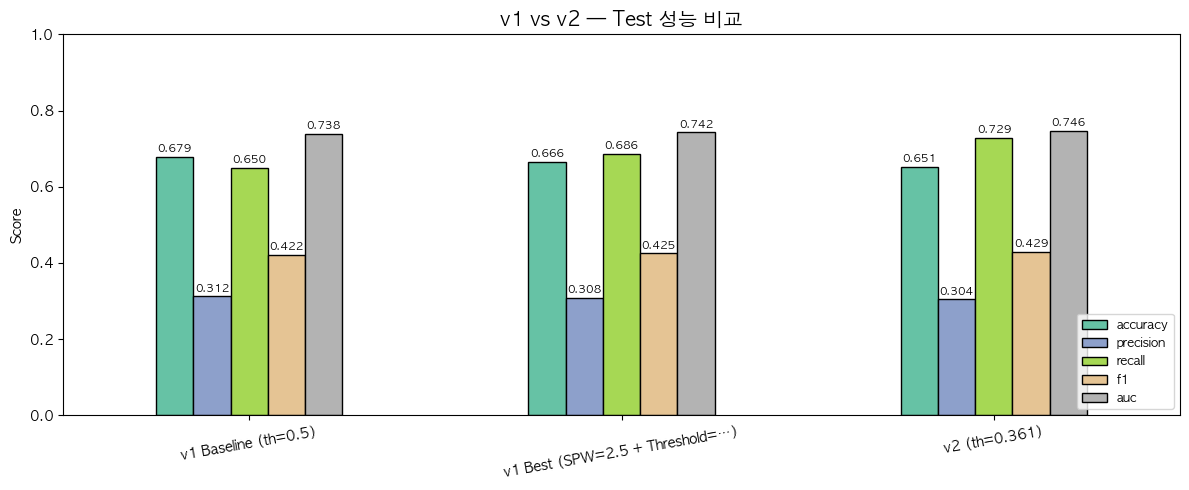

In [44]:
# ============================================================
# 10-5. v1 vs v2 성능 비교
# ============================================================

# v1 baseline (Section 5 결과)
v1_metrics = {
    "accuracy":  test_result["accuracy"],
    "precision": test_result["precision"],
    "recall":    test_result["recall"],
    "f1":        test_result["f1"],
    "auc":       test_result["auc"],
}

# v1 best strategy (Section 9 결과)
v1_best = {
    "accuracy":  comparison.loc[best_strategy, "accuracy"],
    "precision": comparison.loc[best_strategy, "precision"],
    "recall":    comparison.loc[best_strategy, "recall"],
    "f1":        comparison.loc[best_strategy, "f1"],
    "auc":       comparison.loc[best_strategy, "auc"],
}

comp_df = pd.DataFrame({
    "v1 Baseline (th=0.5)":           v1_metrics,
    f"v1 Best ({best_strategy[:20]}…)": v1_best,
    f"v2 (th={best_th_v2:.3f})":      v2_test_metrics,
}).T

print("=" * 80)
print("🏆 v1 vs v2 Test 성능 비교")
print("=" * 80)
print(comp_df.round(4).to_string())

# 개선 폭
f1_improve = v2_test_metrics["f1"] - v1_best["f1"]
auc_improve = v2_test_metrics["auc"] - v1_best["auc"]
print(f"\n📈 v1 Best → v2 개선:")
print(f"   F1  : {v1_best['f1']:.4f} → {v2_test_metrics['f1']:.4f} ({f1_improve:+.4f})")
print(f"   AUC : {v1_best['auc']:.4f} → {v2_test_metrics['auc']:.4f} ({auc_improve:+.4f})")

# ── 시각화 ──
fig, ax = plt.subplots(figsize=(12, 5))
comp_df[["accuracy", "precision", "recall", "f1", "auc"]].plot(
    kind="bar", ax=ax, rot=10, colormap="Set2", edgecolor="black"
)
ax.set_title("v1 vs v2 — Test 성능 비교", fontsize=14)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

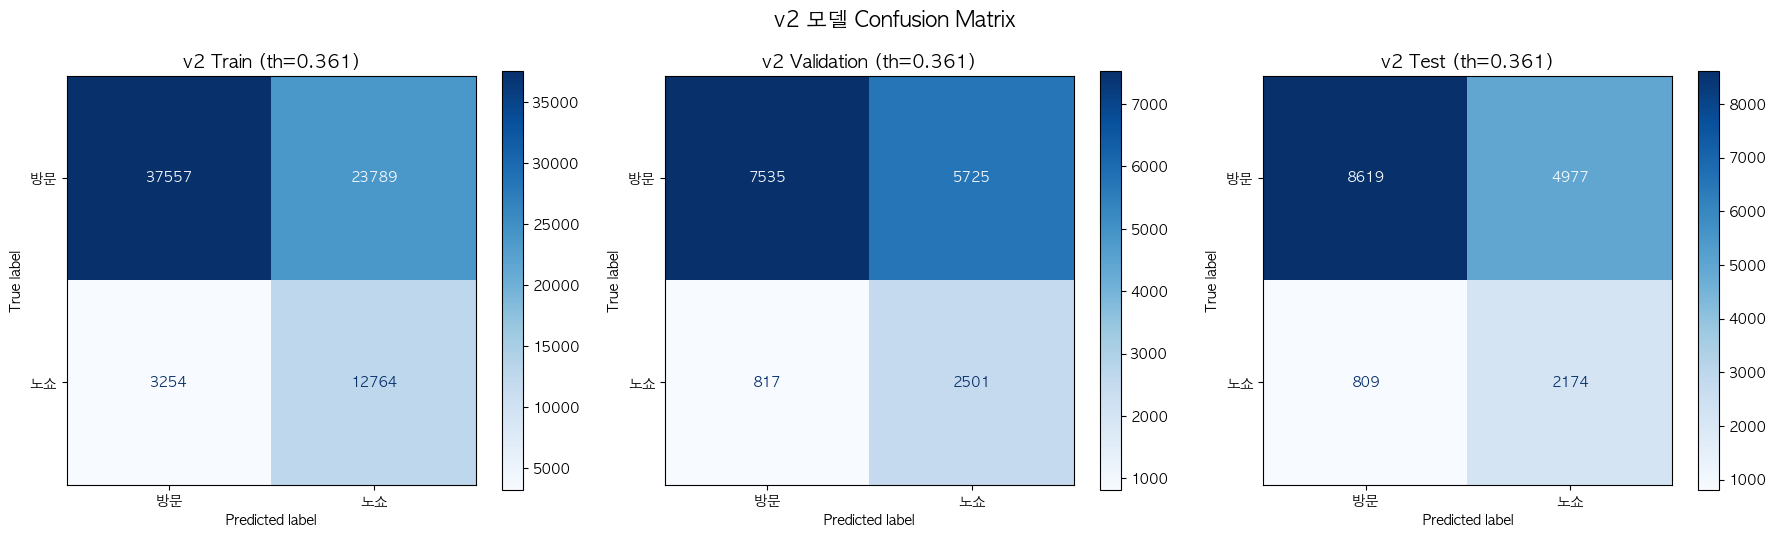

In [45]:
# ============================================================
# 10-6. v2 Confusion Matrix 시각화
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Train
y_pred_v2_train = (model_v2.predict_proba(X_train2)[:, 1] >= best_th_v2).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y_train2, y_pred_v2_train, display_labels=["방문", "노쇼"],
    cmap="Blues", ax=axes[0]
)
axes[0].set_title(f"v2 Train (th={best_th_v2:.3f})", fontsize=13)

# Validation
y_pred_v2_val = (model_v2.predict_proba(X_valid2)[:, 1] >= best_th_v2).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y_valid2, y_pred_v2_val, display_labels=["방문", "노쇼"],
    cmap="Blues", ax=axes[1]
)
axes[1].set_title(f"v2 Validation (th={best_th_v2:.3f})", fontsize=13)

# Test
ConfusionMatrixDisplay.from_predictions(
    y_test2, y_pred_v2_opt, display_labels=["방문", "노쇼"],
    cmap="Blues", ax=axes[2]
)
axes[2].set_title(f"v2 Test (th={best_th_v2:.3f})", fontsize=13)

plt.suptitle("v2 모델 Confusion Matrix", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# 10-7. v2 SHAP 분석
# ============================================================
explainer_v2 = shap.TreeExplainer(model_v2)
shap_values_v2 = explainer_v2(X_test2)

print(f"v2 SHAP values shape: {shap_values_v2.values.shape}")
print("v2 SHAP 분석 완료 ✅")

v2 SHAP values shape: (16579, 20)
v2 SHAP 분석 완료 ✅


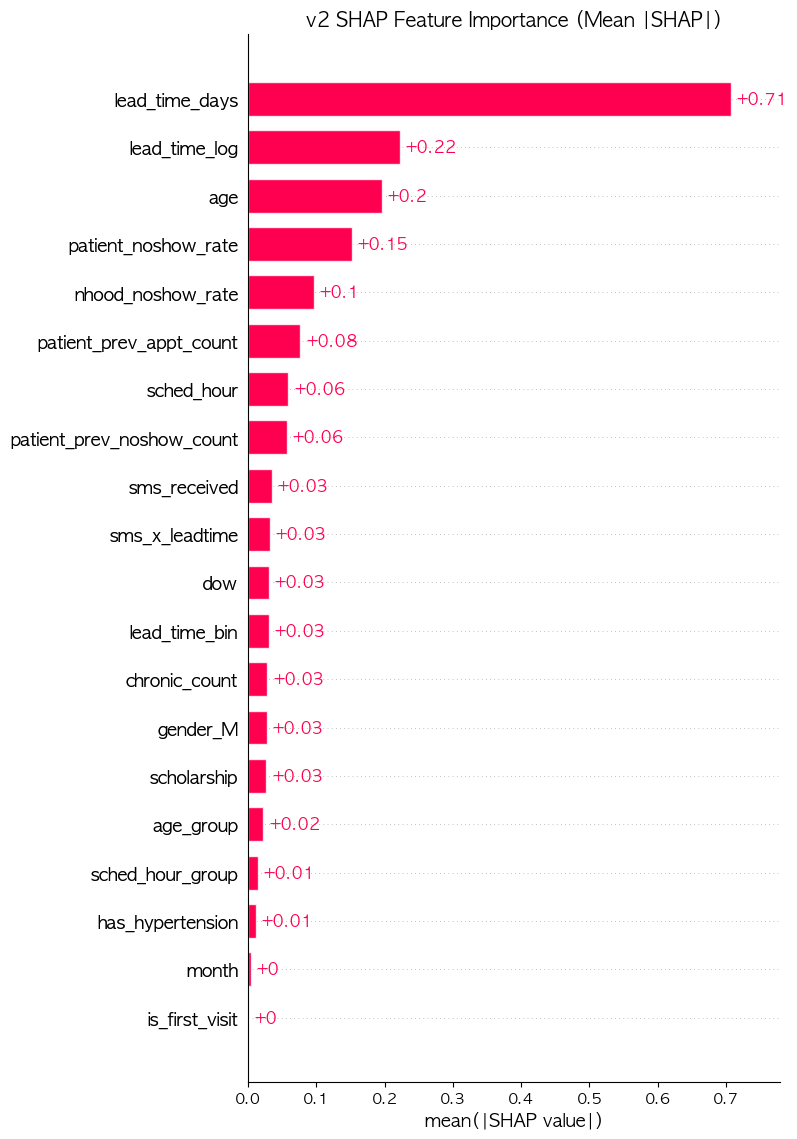

In [47]:
# ── v2 SHAP Bar Plot ──
plt.figure(figsize=(10, 8))
shap.plots.bar(shap_values_v2, max_display=20, show=False)
plt.title("v2 SHAP Feature Importance (Mean |SHAP|)", fontsize=14)
plt.tight_layout()
plt.show()

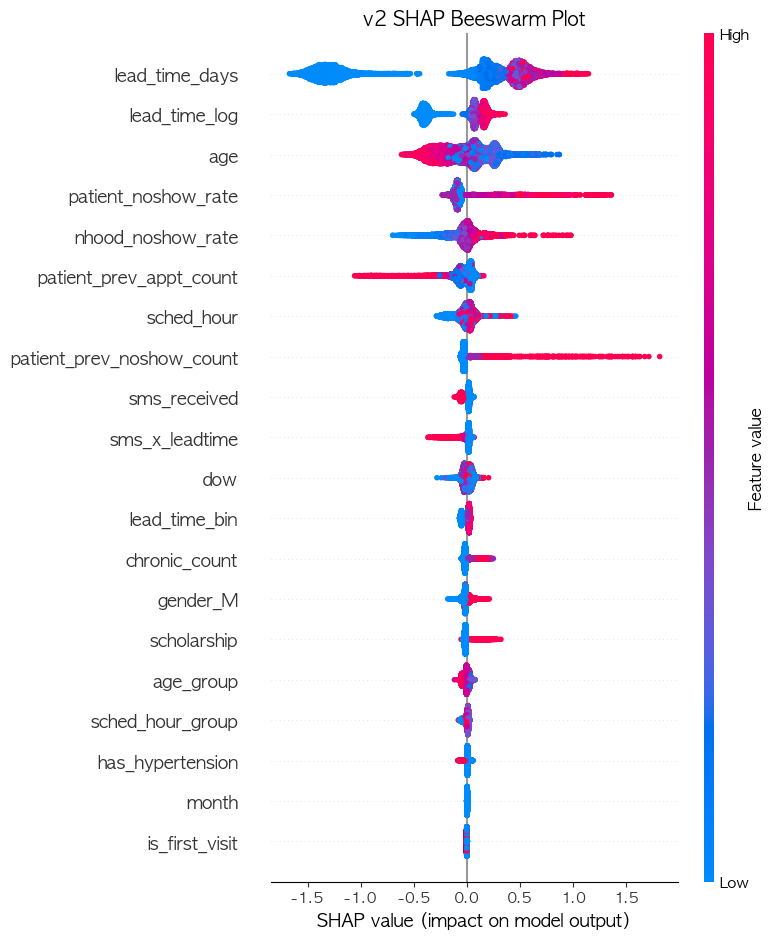

In [48]:
# ── v2 SHAP Beeswarm Plot ──
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_values_v2, max_display=20, show=False)
plt.title("v2 SHAP Beeswarm Plot", fontsize=14)
plt.tight_layout()
plt.show()

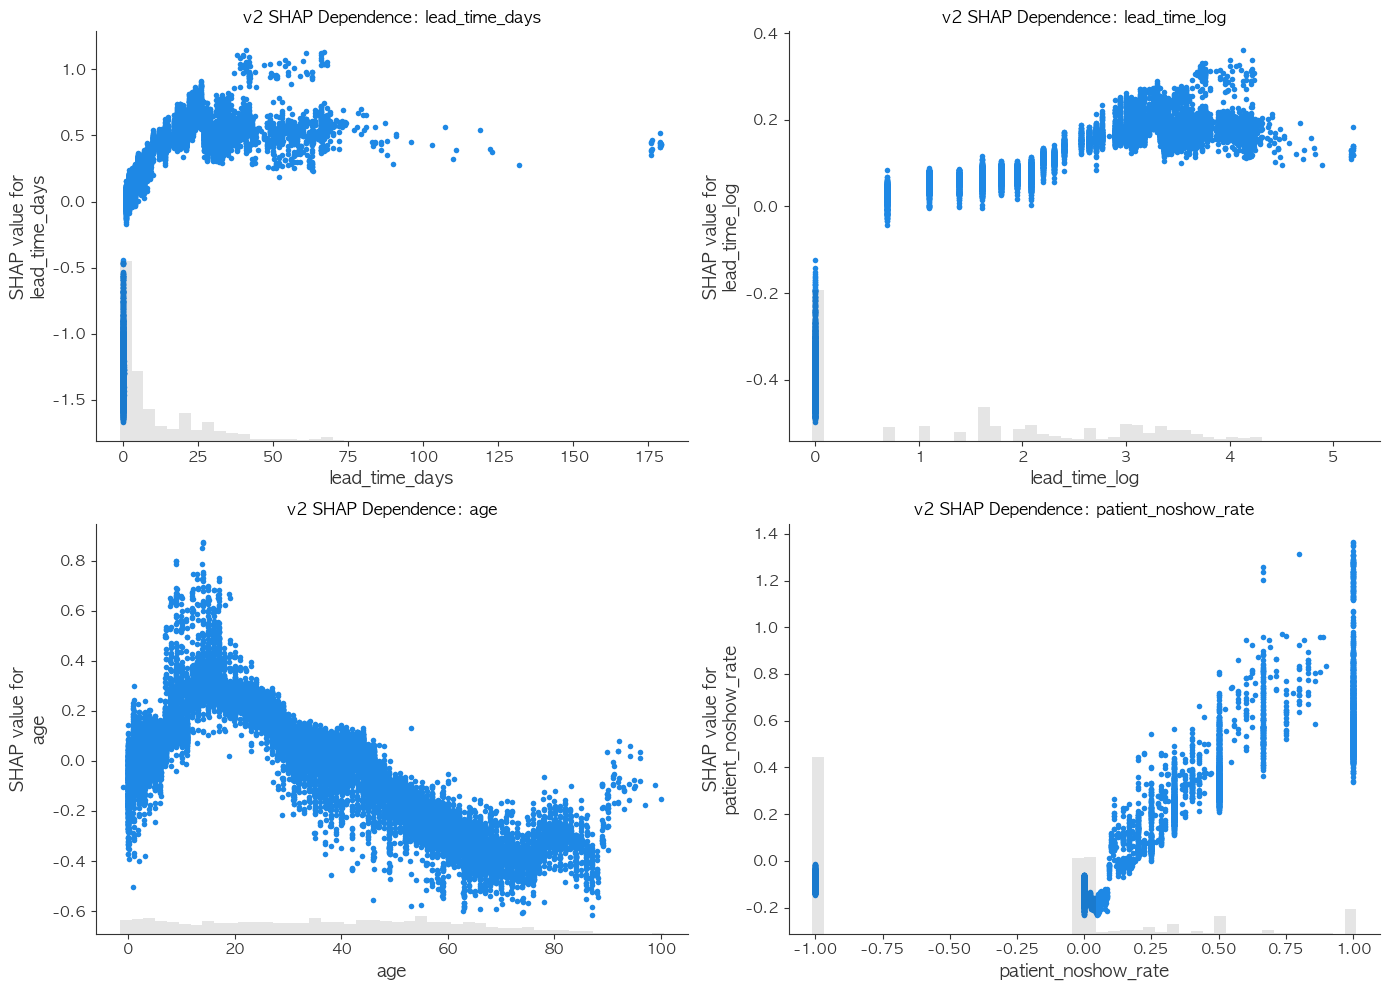


🔑 v2 SHAP 중요도 상위 피처: ['lead_time_days', 'lead_time_log', 'age', 'patient_noshow_rate']


In [49]:
# ── v2 상위 피처 Dependence Plot ──
top_features_v2 = pd.DataFrame({
    "feature": FEATURES_V2,
    "mean_abs_shap": np.abs(shap_values_v2.values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).head(4)["feature"].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.ravel(), top_features_v2):
    shap.plots.scatter(shap_values_v2[:, feat], ax=ax, show=False)
    ax.set_title(f"v2 SHAP Dependence: {feat}", fontsize=12)
plt.tight_layout()
plt.show()
print(f"\n🔑 v2 SHAP 중요도 상위 피처: {top_features_v2}")

In [50]:
# ============================================================
# 10-8. 📋 v2 최종 요약
# ============================================================

# v1 vs v2 SHAP 중요도 비교
shap_v1_imp = pd.DataFrame({
    "feature": FEATURES,
    "v1_mean_shap": np.abs(shap_values.values).mean(axis=0)
}).sort_values("v1_mean_shap", ascending=False)

shap_v2_imp = pd.DataFrame({
    "feature": FEATURES_V2,
    "v2_mean_shap": np.abs(shap_values_v2.values).mean(axis=0)
}).sort_values("v2_mean_shap", ascending=False)

print("=" * 70)
print("📊 v2 최종 분석 요약")
print("=" * 70)

print(f"\n🔧 모델 설정:")
print(f"   피처 수: v1({len(FEATURES)}개) → v2({len(FEATURES_V2)}개)")
print(f"   최적 반복: {model_v2.best_iteration}  |  검증 logloss: {model_v2.best_score:.4f}")
print(f"   최적 Threshold: {best_th_v2:.4f}")

print(f"\n📈 Test 성능:")
print(f"   F1-Score : {v2_test_metrics['f1']:.4f}")
print(f"   ROC-AUC  : {v2_test_metrics['auc']:.4f}")
print(f"   Precision: {v2_test_metrics['precision']:.4f}")
print(f"   Recall   : {v2_test_metrics['recall']:.4f}")
print(f"   Accuracy : {v2_test_metrics['accuracy']:.4f}")

print(f"\n🔑 v2 SHAP 중요도 Top 10:")
for i, row in shap_v2_imp.head(10).iterrows():
    print(f"   {row['feature']:30s} {row['v2_mean_shap']:.4f}")

print(f"\n❌ v1에서 제거한 노이즈 피처:")
removed = [f for f in FEATURES if f not in FEATURES_V2]
for f in removed:
    v1_rank = shap_v1_imp[shap_v1_imp["feature"]==f].index[0] + 1 if f in shap_v1_imp["feature"].values else "?"
    v1_val  = shap_v1_imp[shap_v1_imp["feature"]==f]["v1_mean_shap"].values[0] if f in shap_v1_imp["feature"].values else 0
    print(f"   {f:30s} (v1 SHAP={v1_val:.4f})")

print(f"\n✅ v2에서 새로 추가한 피처:")
added = [f for f in FEATURES_V2 if f not in FEATURES]
for f in added:
    v2_val = shap_v2_imp[shap_v2_imp["feature"]==f]["v2_mean_shap"].values[0] if f in shap_v2_imp["feature"].values else 0
    print(f"   {f:30s} (v2 SHAP={v2_val:.4f})")

📊 v2 최종 분석 요약

🔧 모델 설정:
   피처 수: v1(26개) → v2(20개)
   최적 반복: 340  |  검증 logloss: 0.4984
   최적 Threshold: 0.3614

📈 Test 성능:
   F1-Score : 0.4291
   ROC-AUC  : 0.7457
   Precision: 0.3040
   Recall   : 0.7288
   Accuracy : 0.6510

🔑 v2 SHAP 중요도 Top 10:
   lead_time_days                 0.7065
   lead_time_log                  0.2223
   age                            0.1961
   patient_noshow_rate            0.1524
   nhood_noshow_rate              0.0960
   patient_prev_appt_count        0.0767
   sched_hour                     0.0591
   patient_prev_noshow_count      0.0567
   sms_received                   0.0345
   sms_x_leadtime                 0.0317

❌ v1에서 제거한 노이즈 피처:
   has_diabetes                   (v1 SHAP=0.0181)
   has_alcoholism                 (v1 SHAP=0.0155)
   has_handicap                   (v1 SHAP=0.0052)
   is_weekend                     (v1 SHAP=0.0000)
   is_holiday                     (v1 SHAP=0.0000)
   is_before_holiday              (v1 SHAP=0.0000)
   is_after_

## 11. 🔬 SHAP 기반 피처 선택 실험 (Feature Selection)

v2 SHAP 중요도 순위로 **Top-K 피처만** 사용하여 학습 → 성능 비교  
→ 불필요한 피처를 제거했을 때 성능이 오히려 올라가는 최적 피처 수를 찾습니다.

In [51]:
# ============================================================
# 11-1. SHAP 중요도 순위 확인 & Top-K 실험
# ============================================================

# v2 SHAP 중요도 순위 (이미 계산됨)
shap_rank = pd.DataFrame({
    "feature": FEATURES_V2,
    "mean_abs_shap": np.abs(shap_values_v2.values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

shap_rank.index = shap_rank.index + 1
shap_rank.index.name = "rank"
print("📊 v2 SHAP 중요도 순위 (전체 20개):")
print(shap_rank.to_string())

# 중요도 순서대로 정렬된 피처 리스트
ranked_features = shap_rank["feature"].tolist()
print(f"\n중요도 순: {ranked_features}")

📊 v2 SHAP 중요도 순위 (전체 20개):
                        feature  mean_abs_shap
rank                                          
1                lead_time_days       0.706533
2                 lead_time_log       0.222311
3                           age       0.196107
4           patient_noshow_rate       0.152352
5             nhood_noshow_rate       0.095978
6       patient_prev_appt_count       0.076676
7                    sched_hour       0.059074
8     patient_prev_noshow_count       0.056702
9                  sms_received       0.034474
10               sms_x_leadtime       0.031679
11                          dow       0.030877
12                lead_time_bin       0.030735
13                chronic_count       0.028358
14                     gender_M       0.027422
15                  scholarship       0.027079
16                    age_group       0.022470
17             sched_hour_group       0.014981
18             has_hypertension       0.012054
19                        month  

In [52]:
# ============================================================
# 11-2. Top-K 피처 실험 — K=5,7,9,10,11,12,13,15,20(전체)
# ============================================================
from sklearn.metrics import precision_recall_curve

k_candidates = [5, 7, 9, 10, 11, 12, 13, 15, len(ranked_features)]
fs_results = []

for k in k_candidates:
    top_k = ranked_features[:k]
    
    # 데이터 준비
    Xtr = train2[top_k]
    Xvl = valid2[top_k]
    Xte = test2[top_k]
    
    # 학습 (v2와 동일 파라미터)
    m = xgb.XGBClassifier(**params_v2)
    m.fit(Xtr, y_train2,
          eval_set=[(Xvl, y_valid2)], verbose=0)
    
    # Threshold 최적화 (Validation)
    yp_val = m.predict_proba(Xvl)[:, 1]
    pr, rc, th = precision_recall_curve(y_valid2, yp_val)
    f1_arr = 2 * pr * rc / (pr + rc + 1e-8)
    opt_th = th[np.argmax(f1_arr)]
    val_f1 = f1_arr.max()
    
    # Test 평가 (최적 threshold)
    yp_test = m.predict_proba(Xte)[:, 1]
    yp_cls  = (yp_test >= opt_th).astype(int)
    
    result = {
        "K": k,
        "features": ", ".join(top_k),
        "best_iter": m.best_iteration,
        "threshold": opt_th,
        "val_f1": val_f1,
        "test_accuracy":  accuracy_score(y_test2, yp_cls),
        "test_precision": precision_score(y_test2, yp_cls),
        "test_recall":    recall_score(y_test2, yp_cls),
        "test_f1":        f1_score(y_test2, yp_cls),
        "test_auc":       roc_auc_score(y_test2, yp_test),
    }
    fs_results.append(result)
    
    dropped = ranked_features[k:]
    print(f"  Top-{k:2d} | Val F1={val_f1:.4f} | Test F1={result['test_f1']:.4f}  AUC={result['test_auc']:.4f}  "
          f"(iter={m.best_iteration}, th={opt_th:.3f})  제거: {dropped[:5]}{'...' if len(dropped)>5 else ''}")

fs_df = pd.DataFrame(fs_results)
print("\n✅ 실험 완료")

  Top- 5 | Val F1=0.4310 | Test F1=0.4264  AUC=0.7416  (iter=87, th=0.368)  제거: ['patient_prev_appt_count', 'sched_hour', 'patient_prev_noshow_count', 'sms_received', 'sms_x_leadtime']...
  Top- 7 | Val F1=0.4301 | Test F1=0.4270  AUC=0.7456  (iter=126, th=0.411)  제거: ['patient_prev_noshow_count', 'sms_received', 'sms_x_leadtime', 'dow', 'lead_time_bin']...
  Top- 9 | Val F1=0.4310 | Test F1=0.4313  AUC=0.7457  (iter=397, th=0.338)  제거: ['sms_x_leadtime', 'dow', 'lead_time_bin', 'chronic_count', 'gender_M']...
  Top-10 | Val F1=0.4302 | Test F1=0.4305  AUC=0.7446  (iter=468, th=0.336)  제거: ['dow', 'lead_time_bin', 'chronic_count', 'gender_M', 'scholarship']...
  Top-11 | Val F1=0.4314 | Test F1=0.4318  AUC=0.7462  (iter=318, th=0.348)  제거: ['lead_time_bin', 'chronic_count', 'gender_M', 'scholarship', 'age_group']...
  Top-12 | Val F1=0.4328 | Test F1=0.4252  AUC=0.7447  (iter=502, th=0.366)  제거: ['chronic_count', 'gender_M', 'scholarship', 'age_group', 'sched_hour_group']...
  Top-13 |

🏆 SHAP 기반 피처 선택 실험 결과 (Test Set)
 K  test_f1  test_auc  test_precision  test_recall  test_accuracy  threshold  best_iter
 5 0.426441  0.741646        0.293946     0.776400       0.624223   0.368235         87
 7 0.427029  0.745587        0.321265     0.636607       0.692623   0.410677        126
 9 0.431318  0.745750        0.298304     0.778411       0.630677   0.338149        397
10 0.430495  0.744558        0.297714     0.777070       0.630074   0.336239        468
11 0.431753  0.746171        0.301475     0.760308       0.639906   0.347970        318
12 0.425237  0.744747        0.305507     0.699296       0.659871   0.365922        502
13 0.428064  0.745172        0.299892     0.747570       0.640569   0.349432        395
15 0.429461  0.744421        0.298780     0.763326       0.635081   0.343204        435
20 0.425629  0.743258        0.296875     0.751592       0.635020   0.342165        688

🥇 F1 기준 최적: Top-11 피처
   Test F1=0.4318  |  AUC=0.7462


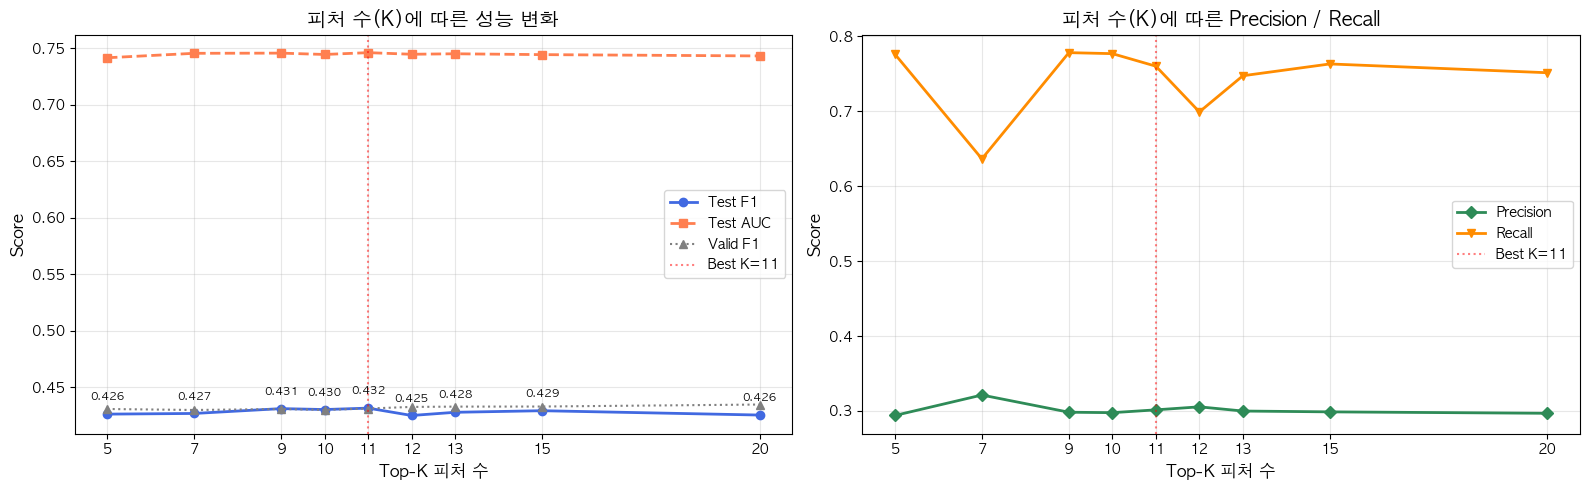

In [53]:
# ============================================================
# 11-3. 결과 비교 테이블 & 시각화
# ============================================================

# 결과 테이블
print("=" * 90)
print("🏆 SHAP 기반 피처 선택 실험 결과 (Test Set)")
print("=" * 90)
display_cols = ["K", "test_f1", "test_auc", "test_precision", "test_recall", "test_accuracy", "threshold", "best_iter"]
print(fs_df[display_cols].to_string(index=False))

# 최적 K 찾기
best_row = fs_df.loc[fs_df["test_f1"].idxmax()]
print(f"\n🥇 F1 기준 최적: Top-{int(best_row['K'])} 피처")
print(f"   Test F1={best_row['test_f1']:.4f}  |  AUC={best_row['test_auc']:.4f}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# F1 & AUC vs K
axes[0].plot(fs_df["K"], fs_df["test_f1"], "o-", label="Test F1", color="royalblue", linewidth=2)
axes[0].plot(fs_df["K"], fs_df["test_auc"], "s--", label="Test AUC", color="coral", linewidth=2)
axes[0].plot(fs_df["K"], fs_df["val_f1"], "^:", label="Valid F1", color="gray", linewidth=1.5)
axes[0].axvline(x=best_row["K"], color="red", linestyle=":", alpha=0.5, label=f"Best K={int(best_row['K'])}")
for _, r in fs_df.iterrows():
    axes[0].annotate(f"{r['test_f1']:.3f}", (r["K"], r["test_f1"]),
                     textcoords="offset points", xytext=(0, 10), fontsize=8, ha="center")
axes[0].set_xlabel("Top-K 피처 수", fontsize=12)
axes[0].set_ylabel("Score", fontsize=12)
axes[0].set_title("피처 수(K)에 따른 성능 변화", fontsize=14)
axes[0].legend(fontsize=10)
axes[0].set_xticks(fs_df["K"])
axes[0].grid(True, alpha=0.3)

# Precision & Recall vs K
axes[1].plot(fs_df["K"], fs_df["test_precision"], "D-", label="Precision", color="seagreen", linewidth=2)
axes[1].plot(fs_df["K"], fs_df["test_recall"], "v-", label="Recall", color="darkorange", linewidth=2)
axes[1].axvline(x=best_row["K"], color="red", linestyle=":", alpha=0.5, label=f"Best K={int(best_row['K'])}")
axes[1].set_xlabel("Top-K 피처 수", fontsize=12)
axes[1].set_ylabel("Score", fontsize=12)
axes[1].set_title("피처 수(K)에 따른 Precision / Recall", fontsize=14)
axes[1].legend(fontsize=10)
axes[1].set_xticks(fs_df["K"])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [54]:
# ============================================================
# 11-4. 최적 K로 최종 모델 학습 + 평가 + SHAP
# ============================================================
best_k = int(best_row["K"])
FEATURES_FINAL = ranked_features[:best_k]

print(f"✅ 최종 선택 피처 (Top-{best_k}):")
for i, f in enumerate(FEATURES_FINAL, 1):
    shap_val = shap_rank[shap_rank["feature"] == f]["mean_abs_shap"].values[0]
    print(f"   {i:2d}. {f:30s} (SHAP={shap_val:.4f})")

dropped_final = ranked_features[best_k:]
print(f"\n❌ 제거된 피처 ({len(dropped_final)}개):")
for f in dropped_final:
    shap_val = shap_rank[shap_rank["feature"] == f]["mean_abs_shap"].values[0]
    print(f"   ✗ {f:30s} (SHAP={shap_val:.4f})")

# ── 최종 모델 학습 ──
X_train_f = train2[FEATURES_FINAL]
X_valid_f = valid2[FEATURES_FINAL]
X_test_f  = test2[FEATURES_FINAL]

model_final = xgb.XGBClassifier(**params_v2)
model_final.fit(
    X_train_f, y_train2,
    eval_set=[(X_train_f, y_train2), (X_valid_f, y_valid2)],
    verbose=100,
)
print(f"\n최적 반복: {model_final.best_iteration}  |  검증 logloss: {model_final.best_score:.4f}")

# ── Threshold 최적화 ──
yp_val_f = model_final.predict_proba(X_valid_f)[:, 1]
pr_f, rc_f, th_f = precision_recall_curve(y_valid2, yp_val_f)
f1_f = 2 * pr_f * rc_f / (pr_f + rc_f + 1e-8)
best_th_final = th_f[np.argmax(f1_f)]
print(f"최적 Threshold: {best_th_final:.4f}  (Valid F1={f1_f.max():.4f})")

# ── Test 평가 ──
yp_test_f = model_final.predict_proba(X_test_f)[:, 1]
yp_cls_f  = (yp_test_f >= best_th_final).astype(int)

final_metrics = {
    "accuracy":  accuracy_score(y_test2, yp_cls_f),
    "precision": precision_score(y_test2, yp_cls_f),
    "recall":    recall_score(y_test2, yp_cls_f),
    "f1":        f1_score(y_test2, yp_cls_f),
    "auc":       roc_auc_score(y_test2, yp_test_f),
}

print(f"\n{'='*60}")
print(f"📊 최종 모델 Test 성능 (Top-{best_k}, th={best_th_final:.4f})")
print(f"{'='*60}")
for kk, vv in final_metrics.items():
    print(f"  {kk:>10s}: {vv:.4f}")
print(f"\n{classification_report(y_test2, yp_cls_f, target_names=['방문(0)', '노쇼(1)'])}")

✅ 최종 선택 피처 (Top-11):
    1. lead_time_days                 (SHAP=0.7065)
    2. lead_time_log                  (SHAP=0.2223)
    3. age                            (SHAP=0.1961)
    4. patient_noshow_rate            (SHAP=0.1524)
    5. nhood_noshow_rate              (SHAP=0.0960)
    6. patient_prev_appt_count        (SHAP=0.0767)
    7. sched_hour                     (SHAP=0.0591)
    8. patient_prev_noshow_count      (SHAP=0.0567)
    9. sms_received                   (SHAP=0.0345)
   10. sms_x_leadtime                 (SHAP=0.0317)
   11. dow                            (SHAP=0.0309)

❌ 제거된 피처 (9개):
   ✗ lead_time_bin                  (SHAP=0.0307)
   ✗ chronic_count                  (SHAP=0.0284)
   ✗ gender_M                       (SHAP=0.0274)
   ✗ scholarship                    (SHAP=0.0271)
   ✗ age_group                      (SHAP=0.0225)
   ✗ sched_hour_group               (SHAP=0.0150)
   ✗ has_hypertension               (SHAP=0.0121)
   ✗ month                          (SHAP

🏆 전체 모델 비교 (Test Set)
                                accuracy  precision  recall      f1     auc
v1 Baseline (26 feats, th=0.5)    0.6791     0.3119  0.6500  0.4216  0.7380
v2 Full (20 feats, th=0.361)      0.6510     0.3040  0.7288  0.4291  0.7457
Final Top-11 (th=0.348)           0.6399     0.3015  0.7603  0.4318  0.7462

📈 v1 Baseline → Final Top-11:
           f1: 0.4216 → 0.4318 (+0.0102)
          auc: 0.7380 → 0.7462 (+0.0082)
    precision: 0.3119 → 0.3015 (-0.0105)
       recall: 0.6500 → 0.7603 (+0.1103)
     accuracy: 0.6791 → 0.6399 (-0.0391)


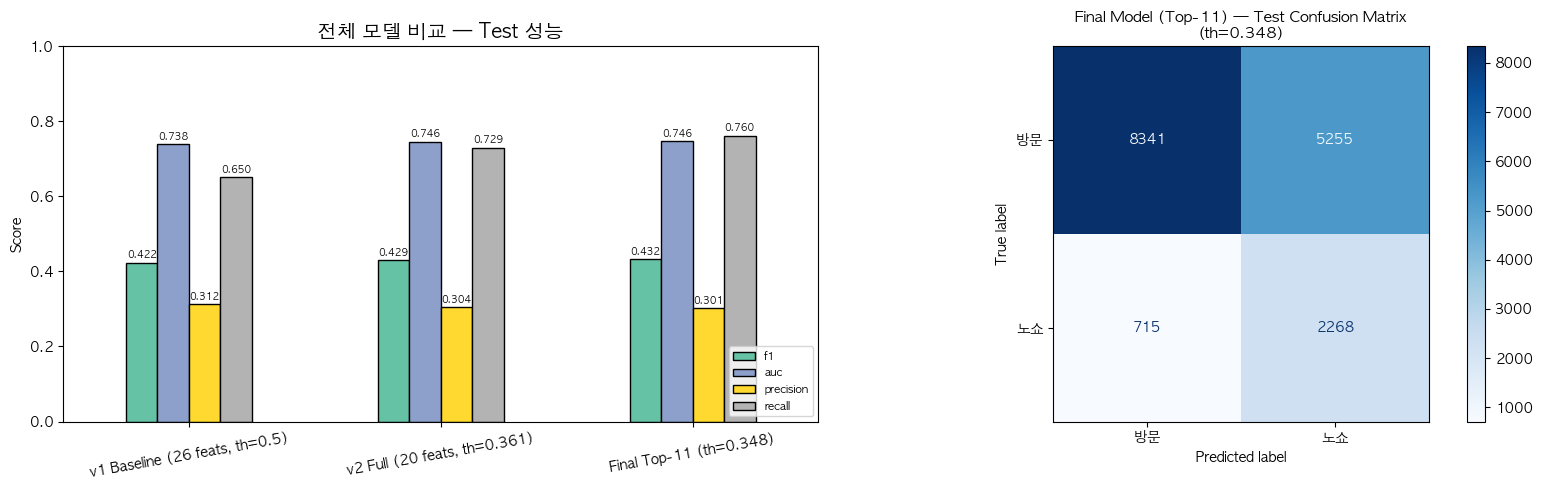

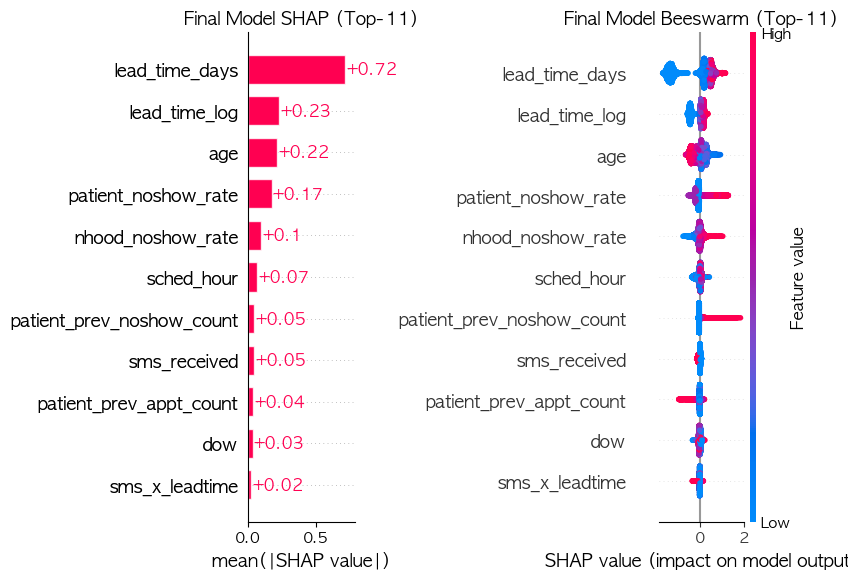


🎯 최종 모델: Top-11 피처, Threshold=0.3480
   F1=0.4318  |  AUC=0.7462  |  Precision=0.3015  |  Recall=0.7603


In [55]:
# ============================================================
# 11-5. 전체 비교 — v1 Baseline → v2 (20) → Final (Top-K)
# ============================================================

all_comp = pd.DataFrame({
    "v1 Baseline (26 feats, th=0.5)":  v1_metrics,
    f"v2 Full (20 feats, th={best_th_v2:.3f})": v2_test_metrics,
    f"Final Top-{best_k} (th={best_th_final:.3f})": final_metrics,
}).T

print("=" * 85)
print("🏆 전체 모델 비교 (Test Set)")
print("=" * 85)
print(all_comp.round(4).to_string())

# 개선 폭
print(f"\n📈 v1 Baseline → Final Top-{best_k}:")
for metric in ["f1", "auc", "precision", "recall", "accuracy"]:
    diff = final_metrics[metric] - v1_metrics[metric]
    print(f"   {metric:>10s}: {v1_metrics[metric]:.4f} → {final_metrics[metric]:.4f} ({diff:+.4f})")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 성능 비교 막대
all_comp[["f1", "auc", "precision", "recall"]].plot(
    kind="bar", ax=axes[0], rot=10, colormap="Set2", edgecolor="black"
)
axes[0].set_title("전체 모델 비교 — Test 성능", fontsize=14)
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", fontsize=7, padding=2)
axes[0].legend(loc="lower right", fontsize=8)

# 최종 Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test2, yp_cls_f, display_labels=["방문", "노쇼"],
    cmap="Blues", ax=axes[1]
)
axes[1].set_title(f"Final Model (Top-{best_k}) — Test Confusion Matrix\n(th={best_th_final:.3f})", fontsize=11)

plt.tight_layout()
plt.show()

# ── 최종 SHAP ──
explainer_final = shap.TreeExplainer(model_final)
shap_values_final = explainer_final(X_test_f)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
shap.plots.bar(shap_values_final, max_display=best_k, ax=axes[0], show=False)
axes[0].set_title(f"Final Model SHAP (Top-{best_k})", fontsize=13)
shap.plots.beeswarm(shap_values_final, max_display=best_k, show=False)
plt.title(f"Final Model Beeswarm (Top-{best_k})", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n🎯 최종 모델: Top-{best_k} 피처, Threshold={best_th_final:.4f}")
print(f"   F1={final_metrics['f1']:.4f}  |  AUC={final_metrics['auc']:.4f}  |  Precision={final_metrics['precision']:.4f}  |  Recall={final_metrics['recall']:.4f}")